# ARIMA and SARIMA ModelNotebook này gộp nội dung từ `tinhdung.ipynb` và `SARIMA.ipynb`, giữ nguyên code gốc, loại các cell code trùng nhau và sắp xếp lại theo từng phần rõ ràng.## Content:1. Setup & Load ECG from Local MIT-BIH2. ECG Preprocessing + HR/RR Extraction3. Stationarity Check (1xx và 2xx)4. ARIMA Identification (ACF/PACF)5. ARIMA Grid Search & Generalization6. ARIMA Fine-Tuning7. ARIMA Rolling Forecast for HR8. ARIMA Rolling Forecast for RR9. SARIMA Rolling Forecast10. SARIMA Tuning & Re-run11. ARIMA vs SARIMA Evaluation12. Plot Comparison: ARIMA vs SARIMA

## 1. Setup & Load ECG from Local MIT-BIH

In [1]:
# =========================
# CELL 1 — Load ECG from Local MIT-BIH Database
# =========================
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os

RECORD = "100"      # đổi record: "100", "101", "102", ...
LEAD = 0            # 0/1 tuỳ record (thường 0=MLII)

# Load từ local directory
DB_PATH = r"C:\Users\MY PC\Downloads\time series project\mitdb"

# Kiểm tra đường dẫn
if not os.path.exists(DB_PATH):
    print(f"✗ Error: Database path not found: {DB_PATH}")
else:
    print(f"✓ Database path: {DB_PATH}")

record = wfdb.rdrecord(os.path.join(DB_PATH, RECORD))

fs = record.fs
sig_names = record.sig_name
ecg = record.p_signal[:, LEAD].astype(float)
t = np.arange(len(ecg)) / fs

print("Record:", RECORD)
print("fs:", fs, "Hz")
print("signals:", sig_names)
print("ecg shape:", ecg.shape, "| duration (s):", t[-1])

âœ“ Database path: C:\Users\MY PC\Downloads\time series project\mitdb
Record: 100
fs: 360 Hz
signals: ['MLII', 'V5']
ecg shape: (650000,) | duration (s): 1805.5527777777777


## 2. ECG Preprocessing + HR/RR Extraction

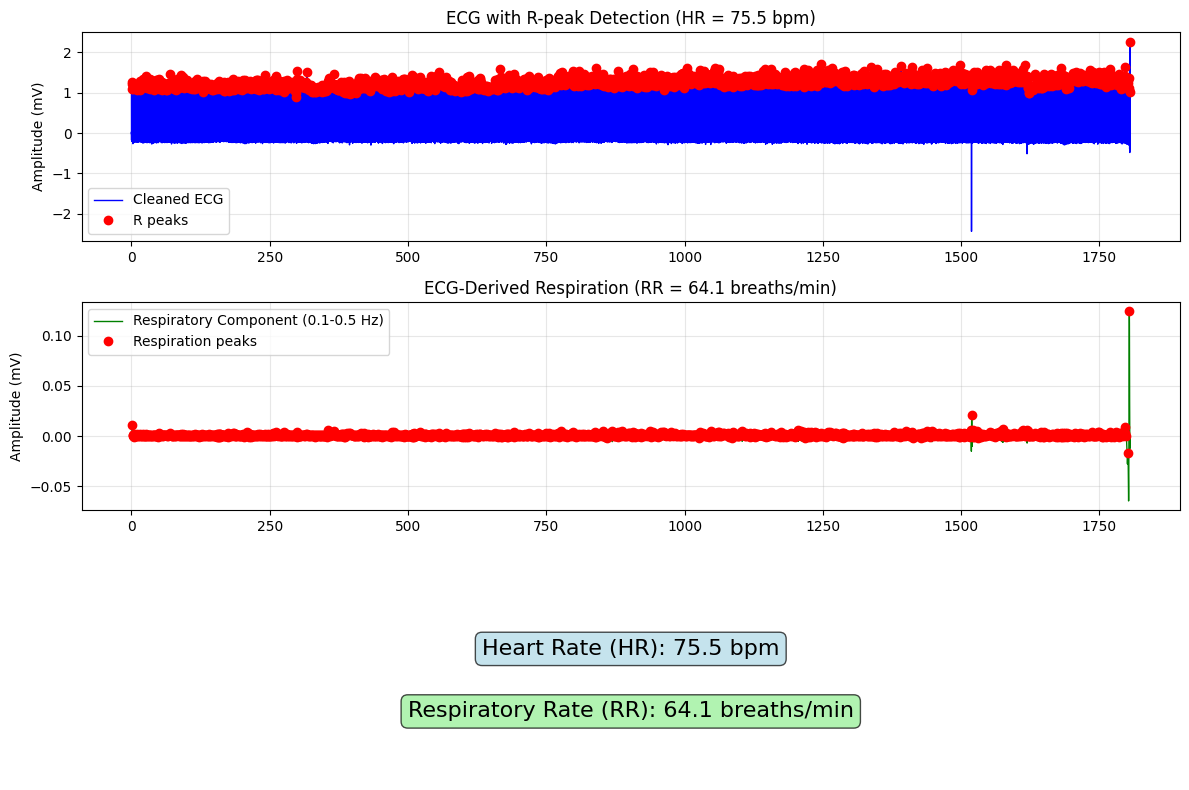

Heart Rate: 75.51 bpm
Respiratory Rate: 64.10 breaths/min


,series,n,mean,std,min,max
0,ECG raw,650000,-0.306299,0.193200,-2.715000,1.435000
1,Baseline estimate,650000,-0.334739,0.058202,-0.570000,0.045000
2,ECG detrended (raw - baseline),650000,0.028440,0.185229,-2.385000,1.755000
3,ECG band-pass (0.5â€“40 Hz),650000,0.000030,0.182315,-2.442642,2.269146
4,ECG cleaned (+ notch 50/60 Hz),650000,0.000030,0.182294,-2.442400,2.265377


In [2]:
# =========================
# CELL 2 — Apply 3 ECG filters:
# 1) Band-pass 0.5–40 Hz
# 2) Remove baseline wander
# 3) Remove power-line noise (50/60 Hz notch)
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, medfilt

# ecg, fs đã có từ CELL 1
x = ecg.astype(float)

# --- (2) Baseline wander removal (median filter 2-stage) ---
# 0.2s median removes QRS; 0.6s median estimates baseline
w1 = int(max(3, (0.2*fs)//2*2 + 1))   # odd
w2 = int(max(3, (0.6*fs)//2*2 + 1))   # odd
baseline = medfilt(medfilt(x, kernel_size=w1), kernel_size=w2)
x_detr = x - baseline

# --- (1) Band-pass 0.5–40 Hz (Butterworth) ---
low, high = 0.5, 40.0
order = 4
nyq = 0.5 * fs
b, a = butter(order, [low/nyq, high/nyq], btype="band")
x_bp = filtfilt(b, a, x_detr)

# --- (3) Power-line notch (choose 50 or 60 Hz) ---
line_freq = 60.0   # đổi thành 50.0 nếu dùng hệ 50Hz
Q = 30.0           # Q cao -> notch hẹp
w0 = line_freq / (fs/2)
bn, an = iirnotch(w0, Q)
x_clean = filtfilt(bn, an, x_bp)

# --- Extract HR (Heart Rate) and RR (Respiratory Rate) from cleaned ECG ---
from scipy.signal import find_peaks

# HR extraction: detect R peaks (QRS complexes)
# Find peaks in cleaned signal with minimum distance
min_distance = int(0.4 * fs)  # minimum 0.4s between beats (150 bpm max)
r_peaks, _ = find_peaks(x_clean, distance=min_distance, height=np.max(x_clean)*0.3)

# Calculate HR from R-R intervals
if len(r_peaks) > 1:
    rr_intervals = np.diff(r_peaks) / fs  # in seconds
    hr = 60.0 / np.mean(rr_intervals)  # convert to bpm
else:
    hr = 0

# RR extraction: use low-frequency component of ECG (0.1-0.5 Hz)
low_rr, high_rr = 0.1, 0.5
order = 2
b_rr, a_rr = butter(order, [low_rr/(fs/2), high_rr/(fs/2)], btype="band")
x_rr = filtfilt(b_rr, a_rr, x_clean)

# Find peaks in RR signal
rr_peaks, _ = find_peaks(x_rr, distance=int(0.5*fs))  # peaks must be >0.5s apart

if len(rr_peaks) > 1:
    resp_intervals = np.diff(rr_peaks) / fs
    rr = 60.0 / np.mean(resp_intervals)  # convert to breaths per minute
else:
    rr = 0

# --- Visualize HR and RR ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Plot 1: ECG with R peaks detected
axes[0].plot(t, x_clean, label="Cleaned ECG", linewidth=1, color='blue')
axes[0].plot(t[r_peaks], x_clean[r_peaks], 'ro', markersize=6, label="R peaks")
axes[0].set_title(f"ECG with R-peak Detection (HR = {hr:.1f} bpm)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Respiratory component
axes[1].plot(t, x_rr, label="Respiratory Component (0.1-0.5 Hz)", linewidth=1, color='green')
axes[1].plot(t[rr_peaks], x_rr[rr_peaks], 'ro', markersize=6, label="Respiration peaks")
axes[1].set_title(f"ECG-Derived Respiration (RR = {rr:.1f} breaths/min)")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: HR and RR summary
axes[2].text(0.5, 0.6, f"Heart Rate (HR): {hr:.1f} bpm", fontsize=16, ha='center', 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[2].text(0.5, 0.3, f"Respiratory Rate (RR): {rr:.1f} breaths/min", fontsize=16, ha='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Heart Rate: {hr:.2f} bpm")
print(f"Respiratory Rate: {rr:.2f} breaths/min")
def basic_stats(y, name):
    y = np.asarray(y).squeeze().astype(float)
    y = y[np.isfinite(y)]
    return pd.Series({
        "series": name,
        "n": len(y),
        "mean": np.mean(y),
        "std":  np.std(y, ddof=1),
        "min":  np.min(y),
        "max":  np.max(y),
    })

stats_df = pd.DataFrame([
    basic_stats(ecg,      "ECG raw"),
    basic_stats(baseline, "Baseline estimate"),
    basic_stats(x_detr,   "ECG detrended (raw - baseline)"),
    basic_stats(x_bp,     "ECG band-pass (0.5–40 Hz)"),
    basic_stats(x_clean,  "ECG cleaned (+ notch 50/60 Hz)"),
])

stats_df

## 3. Stationarity Check (1xx và 2xx)

In [5]:
# =========================
# CELL 4 — Check Stationarity (record 1xx)
# =========================
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
from scipy.ndimage import median_filter
from statsmodels.tsa.stattools import adfuller
import warnings
import os
import gc
warnings.filterwarnings('ignore')

DB_PATH = r"C:\Users\MY PC\Downloads\time series project\mitdb"
# Process all 1xx records
records_list = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                '122', '123', '124']

results = []
print("\nProcessing all 1xx MIT-BIH records...")
print("=" * 70)

for record_id in records_list:
    try:
        record = wfdb.rdrecord(os.path.join(DB_PATH, record_id))
        fs = record.fs
        max_samp = min(len(record.p_signal), int(30 * fs))
        x = record.p_signal[:max_samp, 0].astype(np.float32)
        del record
        gc.collect()
        
        # Baseline removal
        w1 = int(max(3, (0.2*fs)//2*2 + 1))
        w2 = int(max(3, (0.6*fs)//2*2 + 1))
        baseline = median_filter(median_filter(x, size=w1), size=w2)
        x_detr = x - baseline
        del baseline
        
        # Band-pass filter
        b, a = butter(4, [0.5/(fs/2), 40/(fs/2)], btype="band")
        x_bp = filtfilt(b, a, x_detr)
        del x_detr
        
        # Notch filter
        bn, an = iirnotch(60/(fs/2), 30)
        x_clean = filtfilt(bn, an, x_bp)
        del x, x_bp
        gc.collect()
        
        # ADF Test
        p_value = adfuller(x_clean, autolag='AIC')[1]
        results.append({
            'Record': record_id,
            'ADF p-value': p_value,
            'Stationarity': "Stationary" if p_value < 0.05 else "Non-Stationary"
        })
        print(f"Record {record_id}: {results[-1]['Stationarity']} (p={p_value:.6f})")
        del x_clean
        gc.collect()
        
    except Exception as e:
        print(f"Record {record_id}: Error - {type(e).__name__}")
        gc.collect()

df_results = pd.DataFrame(results)
print("\n" + "=" * 70)
print(df_results.to_string())
print("\n✓ Test completed!")


Processing all 1xx MIT-BIH records...
Record 100: Stationary (p=0.000000)
Record 101: Stationary (p=0.000000)
Record 102: Stationary (p=0.000000)
Record 103: Stationary (p=0.000000)
Record 104: Stationary (p=0.000000)
Record 105: Stationary (p=0.000000)
Record 106: Stationary (p=0.000000)
Record 107: Stationary (p=0.000000)
Record 108: Stationary (p=0.000000)
Record 109: Stationary (p=0.000000)
Record 111: Stationary (p=0.000000)
Record 112: Stationary (p=0.000000)
Record 113: Stationary (p=0.000000)
Record 114: Stationary (p=0.000000)
Record 115: Stationary (p=0.000000)
Record 116: Stationary (p=0.000000)
Record 117: Stationary (p=0.000000)
Record 118: Stationary (p=0.000000)
Record 119: Stationary (p=0.000000)
Record 121: Stationary (p=0.000000)
Record 122: Stationary (p=0.000000)
Record 123: Stationary (p=0.000000)
Record 124: Stationary (p=0.000000)

   Record   ADF p-value Stationarity
0     100  7.565321e-30   Stationary
1     101  2.397954e-30   Stationary
2     102  0.000000e+

In [6]:
# =========================
# CELL 5 — Check Stationarity (record 2xx)
# =========================
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch
from scipy.ndimage import median_filter
from statsmodels.tsa.stattools import adfuller
import warnings
import os
import gc
warnings.filterwarnings('ignore')

DB_PATH = r"C:\Users\MY PC\Downloads\time series project\mitdb"
# Process all 2xx records
records_list = ['200', '201', '202', '203', '204', '205', '206', '207', '208', '209',
                '211', '212', '213', '214', '215', '216', '217', '218', '219', '221',
                '222', '223']

results = []
print("\nProcessing all 2xx MIT-BIH records...")
print("=" * 70)

for record_id in records_list:
    try:
        record = wfdb.rdrecord(os.path.join(DB_PATH, record_id))
        fs = record.fs
        max_samp = min(len(record.p_signal), int(30 * fs))
        x = record.p_signal[:max_samp, 0].astype(np.float32)
        del record
        gc.collect()
        
        # Baseline removal
        w1 = int(max(3, (0.2*fs)//2*2 + 1))
        w2 = int(max(3, (0.6*fs)//2*2 + 1))
        baseline = median_filter(median_filter(x, size=w1), size=w2)
        x_detr = x - baseline
        del baseline
        
        # Band-pass filter
        b, a = butter(4, [0.5/(fs/2), 40/(fs/2)], btype="band")
        x_bp = filtfilt(b, a, x_detr)
        del x_detr
        
        # Notch filter
        bn, an = iirnotch(60/(fs/2), 30)
        x_clean = filtfilt(bn, an, x_bp)
        del x, x_bp
        gc.collect()
        
        # ADF Test
        p_value = adfuller(x_clean, autolag='AIC')[1]
        results.append({
            'Record': record_id,
            'ADF p-value': p_value,
            'Stationarity': "Stationary" if p_value < 0.05 else "Non-Stationary"
        })
        print(f"Record {record_id}: {results[-1]['Stationarity']} (p={p_value:.6f})")
        del x_clean
        gc.collect()
        
    except Exception as e:
        print(f"Record {record_id}: Error - {type(e).__name__}")
        gc.collect()

df_results_2xx = pd.DataFrame(results)
print("\n" + "=" * 70)
print(df_results_2xx.to_string())
print("\n✓ Test completed!")


Processing all 2xx MIT-BIH records...
Record 200: Stationary (p=0.000000)
Record 201: Stationary (p=0.000000)
Record 202: Stationary (p=0.000000)
Record 203: Stationary (p=0.000000)
Record 204: Error - FileNotFoundError
Record 205: Stationary (p=0.000000)
Record 206: Error - FileNotFoundError
Record 207: Stationary (p=0.000000)
Record 208: Stationary (p=0.000000)
Record 209: Stationary (p=0.000000)
Record 211: Error - FileNotFoundError
Record 212: Stationary (p=0.000000)
Record 213: Stationary (p=0.000000)
Record 214: Stationary (p=0.000000)
Record 215: Stationary (p=0.000000)
Record 216: Error - FileNotFoundError
Record 217: Stationary (p=0.000000)
Record 218: Error - FileNotFoundError
Record 219: Stationary (p=0.000000)
Record 221: Stationary (p=0.000000)
Record 222: Stationary (p=0.000000)
Record 223: Stationary (p=0.000000)

   Record   ADF p-value Stationarity
0     200  7.021027e-30   Stationary
1     201  7.566993e-30   Stationary
2     202  7.352738e-30   Stationary
3     203 

## 4. ARIMA Identification (ACF/PACF)

Chosen d = 0 (ADF p-value after differencing = 0.004498)
ACF/PACF sáº½ Ä‘Æ°á»£c váº½ trÃªn chuá»—i sau differencing (y_stat).


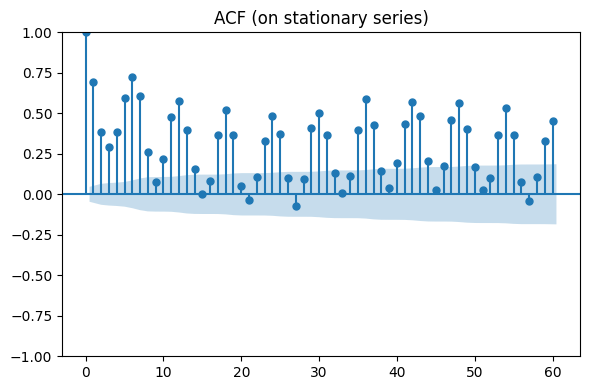

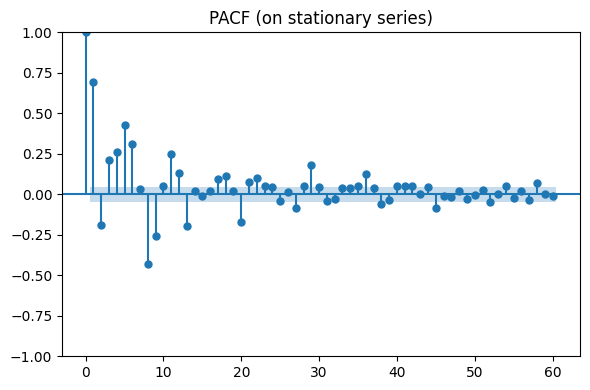

In [4]:
# ====== IMPORTS ======
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display

# ====== Extract HR time series from cleaned ECG ======
# Use x_clean from cell 2 to extract HR time series
def hampel_filter(x, window=10, n_sigmas=3.0):
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    k = 1.4826
    y = x.copy()
    for i in range(n):
        lo, hi = max(0, i-window), min(n, i+window+1)
        w = x[lo:hi]
        med = np.nanmedian(w)
        mad = k * np.nanmedian(np.abs(w - med))
        if not np.isfinite(mad) or mad < 1e-9:
            continue
        if np.abs(x[i] - med) > n_sigmas * mad:
            y[i] = med
    return y

# Detect R-peaks from cleaned ECG
rpeaks_arr = r_peaks  # from cell 2
rr_intervals = np.diff(rpeaks_arr) / fs  # in seconds
rr_intervals = np.clip(rr_intervals, 0.3, 2.5)  # physiological limits
rr_intervals = hampel_filter(rr_intervals, window=10, n_sigmas=3.0)

# Convert to HR
hr_clean = 60.0 / rr_intervals
hr_clean = np.clip(hr_clean, 30, 200)  # physiological HR limits
hr_clean = hampel_filter(hr_clean, window=10, n_sigmas=3.0)
t_hr = rpeaks_arr[1:] / fs

# Resample HR to 1 Hz for ARIMA
t_end = float(np.floor(len(ecg) / fs))
t_grid = np.arange(0, t_end + 1, 1.0)
mask = np.isfinite(hr_clean) & np.isfinite(t_hr)
hr_reg_clean = np.interp(t_grid, t_hr[mask], hr_clean[mask])

# ====== 0) Chọn chuỗi để làm ARIMA ======
# Khuyến nghị:
# - HR: dùng hr_reg_clean (1 Hz)
# - RR: nếu muốn test theo beat-index, dùng rr_clean
y_raw = hr_reg_clean   # đổi thành rr_clean nếu bạn muốn làm cho RR

y_raw = np.asarray(y_raw, dtype=float)
y_raw = y_raw[np.isfinite(y_raw)]

# ====== 1) Chọn d bằng ADF (diff đến khi stationary) ======
def choose_d_by_adf(y, alpha=0.05, max_d=2):
    y = y.copy()
    d = 0
    while d <= max_d:
        pval = adfuller(y, autolag="AIC", regression="c")[1]
        if pval < alpha:
            return d, y, pval
        y = np.diff(y)
        d += 1
    return d, y, pval  # có thể vẫn chưa pass nếu dữ liệu rất "regime-switching"

d, y_stat, pval = choose_d_by_adf(y_raw, alpha=0.05, max_d=2)
print(f"Chosen d = {d} (ADF p-value after differencing = {pval:.4g})")
print("ACF/PACF sẽ được vẽ trên chuỗi sau differencing (y_stat).")

# ====== 2) Vẽ ACF & PACF để nhìn cut-off ======
max_lag = 60  # 1Hz => 60 lag ~ 60s. Bạn có thể đổi 30/120/300 tuỳ

fig_acf, ax_acf = plt.subplots(figsize=(6,4))
plot_acf(y_stat, lags=max_lag, ax=ax_acf)
ax_acf.set_title("ACF (on stationary series)")
fig_acf.tight_layout()
plt.show()
plt.close(fig_acf)

fig_pacf, ax_pacf = plt.subplots(figsize=(6,4))
plot_pacf(y_stat, lags=max_lag, method="ywm", ax=ax_pacf)
ax_pacf.set_title("PACF (on stationary series)")
fig_pacf.tight_layout()
plt.show()
plt.close(fig_pacf)



## 5. ARIMA Grid Search & Generalization

Tá»”NG Há»¢P TÃŒM (p,d,q) Tá»I Æ¯U TRÃŠN NHIá»€U RECORDS
Test records: ['200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '211', '212', '213', '214', '215', '216', '217', '218', '219', '221', '222', '223']
P range: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Q range: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Max duration per record: 60s

Step 1: Loading and processing records...
  Processing 200... Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
âœ“ (61 samples)
  Processing 201... Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
âœ“ (61 samples)
  Processing 202... Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
âœ“ (61 samples)
  Processing 203... Learning initial si

,p,d,q,n_success,avg_AIC,std_AIC,avg_BIC
0,3,0,2,17,360.434219,135.337299,375.210336
1,2,0,3,17,360.542700,133.507520,375.318817
2,2,0,2,17,361.453858,133.072858,374.119101
3,4,0,2,17,361.844922,134.857152,378.731913
4,5,0,5,17,361.872661,136.804577,387.203148
5,3,0,3,17,361.932104,133.747092,378.819095
6,4,0,5,17,362.389265,135.096535,385.608877
7,5,0,2,17,362.389273,134.980690,381.387138
8,6,0,5,17,362.462358,137.042614,389.903719
9,5,0,4,17,362.644120,135.391262,385.863733



ðŸ† BEST MODEL: ARIMA(3,0,2)
   Average AIC: 360.43 Â± 135.34
   Average BIC: 375.21
   Success rate: 17/17 records

Visualizing top 10 models by average AIC...


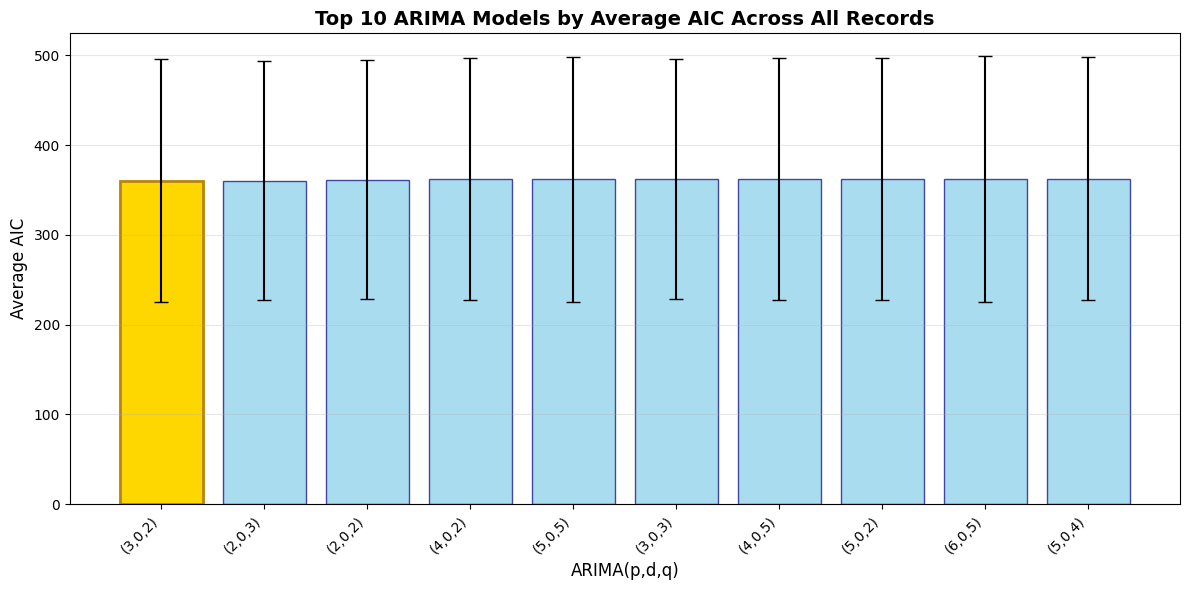


âœ“ Analysis complete!
Recommendation: Use ARIMA(3,0,2) for HR forecasting

ÄÃNH GIÃ MODEL Tá»I Æ¯U TRÃŠN TEST RECORDS (1XX)

Testing model: ARIMA(3,0,2)
Test records: 23 records (1xx series)

Loading test records...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
  âœ“ 100: 61 samples
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
  âœ“ 101: 61 samples
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
  âœ“ 102: 61 samples
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
  âœ“ 103: 61 samples
Learning initial signal parameters...
Found 8 beats durin

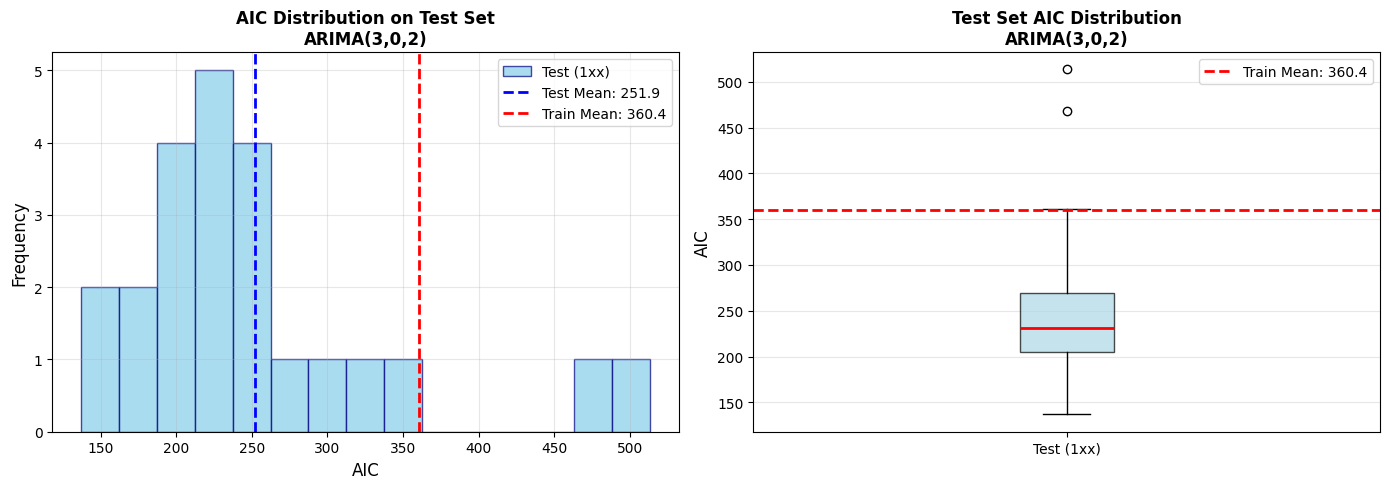


âœ“ Test set evaluation complete!


In [6]:
# ====== TÌM (p,d,q) TỐI ƯU TRÊN NHIỀU RECORDS ======
# Test nhiều records để tìm model ARIMA tổng quát tốt nhất
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, medfilt, find_peaks
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display
import warnings
import os
import gc
warnings.filterwarnings('ignore')

# ====== Helper Functions ======
def remove_baseline_median(x, fs, w1_sec=0.2, w2_sec=0.6):
    w1 = int(max(3, (w1_sec*fs)//2*2 + 1))
    w2 = int(max(3, (w2_sec*fs)//2*2 + 1))
    b1 = medfilt(x, kernel_size=w1)
    baseline = medfilt(b1, kernel_size=w2)
    return x - baseline

def butter_bandpass(x, fs, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def notch(x, fs, f0=60.0, Q=30.0):
    w0 = f0 / (fs/2)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, x)

def detect_rpeaks(ecg_filt, fs):
    try:
        from wfdb import processing
        r = processing.xqrs_detect(sig=ecg_filt.astype(float), fs=fs)
        r = np.asarray(r, dtype=int)
        if len(r) > 20:
            return r
    except Exception:
        pass
    distance = int(0.25 * fs)
    prom = np.std(ecg_filt) * 0.5
    r, _ = find_peaks(ecg_filt, distance=distance, prominence=prom)
    return r.astype(int)

def hampel(x, window=10, n_sigmas=3.0):
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    k = 1.4826
    y = x.copy()
    for i in range(n):
        lo, hi = max(0, i-window), min(n, i+window+1)
        w = x[lo:hi]
        med = np.nanmedian(w)
        mad = k * np.nanmedian(np.abs(w - med))
        if not np.isfinite(mad) or mad < 1e-9:
            continue
        if np.abs(x[i] - med) > n_sigmas * mad:
            y[i] = med
    return y

def process_record_to_hr(record_id, db_path=None, max_duration=60):
    """
    Load record, clean ECG, extract HR resampled at 1 Hz
    Returns: hr_reg (1D array) or None if failed
    """
    try:
        if db_path:
            record = wfdb.rdrecord(os.path.join(db_path, record_id))
        else:
            record = wfdb.rdrecord(record_id, pn_dir="mitdb")
        
        fs = record.fs
        max_samp = min(len(record.p_signal), int(max_duration * fs))
        x = record.p_signal[:max_samp, 0].astype(float)
        del record
        gc.collect()
        
        # Apply filters
        x_detr = remove_baseline_median(x, fs)
        x_bp = butter_bandpass(x_detr, fs)
        x_clean = notch(x_bp, fs)
        del x, x_detr, x_bp
        gc.collect()
        
        # Detect R-peaks
        rpeaks = detect_rpeaks(x_clean, fs)
        if len(rpeaks) < 10:
            return None
            
        rr = np.diff(rpeaks) / fs
        rr = np.clip(rr, 0.25, 2.5)
        rr = hampel(rr, window=10, n_sigmas=3.0)
        
        hr = 60.0 / rr
        hr = np.clip(hr, 30, 220)
        hr = hampel(hr, window=10, n_sigmas=3.0)
        t_hr = rpeaks[1:] / fs
        
        # Resample to 1 Hz
        t_end = int(np.floor(max_samp / fs))
        t_grid = np.arange(0, t_end + 1, 1.0)
        mask = np.isfinite(hr) & np.isfinite(t_hr)
        if np.sum(mask) < 10:
            return None
        hr_reg = np.interp(t_grid, t_hr[mask], hr[mask]).astype(float)
        hr_reg = hr_reg[np.isfinite(hr_reg)]
        
        del x_clean, rpeaks, rr, hr
        gc.collect()
        
        return hr_reg if len(hr_reg) > 30 else None
    except Exception as e:
        print(f"  Record {record_id}: Error - {type(e).__name__}")
        gc.collect()
        return None

def choose_d_by_adf(y, alpha=0.05, max_d=2):
    """Determine d by differencing until stationary"""
    y = y.copy()
    d = 0
    while d <= max_d:
        pval = adfuller(y, autolag="AIC", regression="c")[1]
        if pval < alpha:
            return d
        y = np.diff(y)
        d += 1
    return d

# ====== Main: Test ARIMA on multiple records ======
DB_PATH = r"C:\Users\MY PC\Downloads\time series project\mitdb"
TEST_RECORDS = ['200', '201', '202', '203', '204', '205', '206', '207', '208', '209',
                '211', '212', '213', '214', '215', '216', '217', '218', '219', '221',
                '222', '223']

# Define candidate (p,q) ranges
P_RANGE = [0, 1, 2, 3, 4, 5, 6, 7, 8]
Q_RANGE = [0, 1, 2, 3, 4, 5, 6, 7, 8]

print("=" * 80)
print("TỔNG HỢP TÌM (p,d,q) TỐI ƯU TRÊN NHIỀU RECORDS")
print("=" * 80)
print(f"Test records: {TEST_RECORDS}")
print(f"P range: {P_RANGE}")
print(f"Q range: {Q_RANGE}")
print(f"Max duration per record: 60s")
print("=" * 80)

# Step 1: Load and process all records
print("\nStep 1: Loading and processing records...")
hr_data = {}
for record_id in TEST_RECORDS:
    print(f"  Processing {record_id}...", end=" ")
    hr = process_record_to_hr(record_id, db_path=DB_PATH, max_duration=60)
    if hr is not None and len(hr) > 30:
        hr_data[record_id] = hr
        print(f"✓ ({len(hr)} samples)")
    else:
        print("✗ Failed or too short")

print(f"\n✓ Successfully loaded {len(hr_data)} records")
print("=" * 80)

# Step 2: For each record, determine d
print("\nStep 2: Determining d for each record...")
d_values = {}
for record_id, hr in hr_data.items():
    d = choose_d_by_adf(hr, alpha=0.05, max_d=2)
    d_values[record_id] = d
    print(f"  {record_id}: d = {d}")

# Use most common d
from collections import Counter
d_common = Counter(d_values.values()).most_common(1)[0][0]
print(f"\n✓ Most common d = {d_common} (will use this for all models)")
print("=" * 80)

# Step 3: Grid search (p,q) across all records
print(f"\nStep 3: Grid search (p,q) with d={d_common} on all records...")
print(f"Total combinations to test: {len(P_RANGE) * len(Q_RANGE)}")

all_results = []
for p in P_RANGE:
    for q in Q_RANGE:
        aic_list = []
        bic_list = []
        success_count = 0
        
        for record_id, hr in hr_data.items():
            try:
                model = ARIMA(hr, order=(p, d_common, q))
                result = model.fit()
                aic_list.append(result.aic)
                bic_list.append(result.bic)
                success_count += 1
            except Exception:
                pass
        
        if success_count > 0:
            avg_aic = np.mean(aic_list)
            avg_bic = np.mean(bic_list)
            std_aic = np.std(aic_list)
            
            all_results.append({
                'p': p,
                'd': d_common,
                'q': q,
                'n_success': success_count,
                'avg_AIC': avg_aic,
                'std_AIC': std_aic,
                'avg_BIC': avg_bic,
            })
        
        if (p * len(Q_RANGE) + q + 1) % 10 == 0:
            print(f"  Progress: {p * len(Q_RANGE) + q + 1}/{len(P_RANGE) * len(Q_RANGE)}")

print(f"\n✓ Grid search complete")
print("=" * 80)

# Step 4: Rank and display results
print("\nStep 4: Top 15 models by average AIC:")
df_results = pd.DataFrame(all_results).sort_values('avg_AIC').reset_index(drop=True)
display(df_results.head(15))

# Best model
best = df_results.iloc[0]
print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: ARIMA({int(best.p)},{int(best.d)},{int(best.q)})")
print(f"   Average AIC: {best.avg_AIC:.2f} ± {best.std_AIC:.2f}")
print(f"   Average BIC: {best.avg_BIC:.2f}")
print(f"   Success rate: {int(best.n_success)}/{len(hr_data)} records")
print("=" * 80)

# Visualize top 10 models
print("\nVisualizing top 10 models by average AIC...")
top10 = df_results.head(10)
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(top10))
labels = [f"({int(r.p)},{int(r.d)},{int(r.q)})" for _, r in top10.iterrows()]

ax.bar(x_pos, top10['avg_AIC'], yerr=top10['std_AIC'], 
       capsize=5, alpha=0.7, color='skyblue', edgecolor='navy')
ax.set_xlabel('ARIMA(p,d,q)', fontsize=12)
ax.set_ylabel('Average AIC', fontsize=12)
ax.set_title('Top 10 ARIMA Models by Average AIC Across All Records', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Highlight best model
ax.bar(0, top10.iloc[0]['avg_AIC'], color='gold', edgecolor='darkgoldenrod', linewidth=2)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")
print(f"Recommendation: Use ARIMA({int(best.p)},{int(best.d)},{int(best.q)}) for HR forecasting")

# ====== ĐÁNH GIÁ MODEL TỐI ƯU TRÊN TEST SET (1XX RECORDS) ======
print("\n" + "=" * 80)
print("ĐÁNH GIÁ MODEL TỐI ƯU TRÊN TEST RECORDS (1XX)")
print("=" * 80)

TEST_RECORDS_1XX = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
                    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
                    '122', '123', '124']

# Use best model from training
p_best = int(best.p)
d_best = int(best.d)
q_best = int(best.q)

print(f"\nTesting model: ARIMA({p_best},{d_best},{q_best})")
print(f"Test records: {len(TEST_RECORDS_1XX)} records (1xx series)")

# Load test records
print("\nLoading test records...")
hr_data_test = {}
for record_id in TEST_RECORDS_1XX:
    hr = process_record_to_hr(record_id, db_path=DB_PATH, max_duration=60)
    if hr is not None and len(hr) > 30:
        hr_data_test[record_id] = hr
        print(f"  ✓ {record_id}: {len(hr)} samples")

print(f"\n✓ Loaded {len(hr_data_test)}/{len(TEST_RECORDS_1XX)} test records")

# Evaluate on test set
print("\n" + "=" * 80)
print("Evaluating model performance on test set...")
test_results = []
aic_test_list = []
bic_test_list = []

for record_id, hr in hr_data_test.items():
    try:
        model = ARIMA(hr, order=(p_best, d_best, q_best))
        result = model.fit()
        aic_test_list.append(result.aic)
        bic_test_list.append(result.bic)
        test_results.append({
            'Record': record_id,
            'AIC': result.aic,
            'BIC': result.bic,
            'Status': '✓ Success'
        })
        print(f"  {record_id}: AIC={result.aic:.2f}, BIC={result.bic:.2f}")
    except Exception as e:
        test_results.append({
            'Record': record_id,
            'AIC': None,
            'BIC': None,
            'Status': f'✗ {type(e).__name__}'
        })
        print(f"  {record_id}: ✗ Failed")

# Summary statistics
df_test_results = pd.DataFrame(test_results)
print("\n" + "=" * 80)
print("TEST SET PERFORMANCE SUMMARY:")
print("-" * 80)
print(f"Model: ARIMA({p_best},{d_best},{q_best})")
print(f"Test records evaluated: {len(aic_test_list)}/{len(hr_data_test)}")
print(f"\nTest Set Metrics:")
print(f"  Average AIC: {np.mean(aic_test_list):.2f} ± {np.std(aic_test_list):.2f}")
print(f"  Average BIC: {np.mean(bic_test_list):.2f} ± {np.std(bic_test_list):.2f}")
print(f"  Min AIC:     {np.min(aic_test_list):.2f}")
print(f"  Max AIC:     {np.max(aic_test_list):.2f}")

# Compare train vs test
print(f"\nComparison (Train 2xx vs Test 1xx):")
print(f"  Train AIC: {best.avg_AIC:.2f} ± {best.std_AIC:.2f}")
print(f"  Test AIC:  {np.mean(aic_test_list):.2f} ± {np.std(aic_test_list):.2f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AIC distribution on test set
axes[0].hist(aic_test_list, bins=15, alpha=0.7, color='skyblue', edgecolor='navy', label='Test (1xx)')
axes[0].axvline(np.mean(aic_test_list), color='blue', linestyle='--', linewidth=2, label=f'Test Mean: {np.mean(aic_test_list):.1f}')
axes[0].axvline(best.avg_AIC, color='red', linestyle='--', linewidth=2, label=f'Train Mean: {best.avg_AIC:.1f}')
axes[0].set_xlabel('AIC', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'AIC Distribution on Test Set\nARIMA({p_best},{d_best},{q_best})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot of test set AIC
axes[1].boxplot([aic_test_list], 
                labels=['Test (1xx)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].axhline(best.avg_AIC, color='red', linestyle='--', linewidth=2, label=f'Train Mean: {best.avg_AIC:.1f}')
axes[1].set_ylabel('AIC', fontsize=12)
axes[1].set_title(f'Test Set AIC Distribution\nARIMA({p_best},{d_best},{q_best})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✓ Test set evaluation complete!")
print("=" * 80)

## 6. ARIMA Fine-Tuning

FINE-TUNING GRID SEARCH: Kiá»ƒm tra tá»‘i Æ°u xung quanh best model
Best model tá»« tÃ¬m kiáº¿m trÆ°á»›c: ARIMA(3,0,2)
Sáº½ test grid xung quanh: p âˆˆ [1, 5], q âˆˆ [0, 4]

Fine-tuning grid:
  P values: [1, 2, 3, 4, 5]
  D value: 0 (fixed)
  Q values: [0, 1, 2, 3, 4]
  Total combinations: 5 x 5 = 25

Step 1: Evaluating on TRAIN set (2xx records)...
  ARIMA(1,0,0): AIC=375.99 (n=17)
  ARIMA(1,0,1): AIC=372.68 (n=17)
  ARIMA(1,0,2): AIC=371.24 (n=17)
  ARIMA(1,0,3): AIC=371.13 (n=17)
  ARIMA(1,0,4): AIC=370.49 (n=17)
  ARIMA(2,0,0): AIC=369.10 (n=17)
  ARIMA(2,0,1): AIC=367.56 (n=17)
  ARIMA(2,0,2): AIC=361.45 (n=17)
  ARIMA(2,0,3): AIC=360.54 (n=17)
  ARIMA(2,0,4): AIC=364.63 (n=17)
  ARIMA(3,0,0): AIC=366.95 (n=17)
  ARIMA(3,0,1): AIC=368.01 (n=17)
  ARIMA(3,0,2): AIC=360.43 (n=17)
  ARIMA(3,0,3): AIC=361.93 (n=17)
  ARIMA(3,0,4): AIC=363.55 (n=17)
  ARIMA(4,0,0): AIC=367.17 (n=17)
  ARIMA(4,0,1): AIC=368.42 (n=17)
  ARIMA(4,0,2): AIC=361.84 (n=17)
  ARIMA(4,0,3): AIC=362.98 (n=17)
  

FINE-TUNING GRID SEARCH: Kiá»ƒm tra tá»‘i Æ°u xung quanh best model
Best model tá»« tÃ¬m kiáº¿m trÆ°á»›c: ARIMA(3,0,2)
Sáº½ test grid xung quanh: p âˆˆ [1, 5], q âˆˆ [0, 4]

Fine-tuning grid:
  P values: [1, 2, 3, 4, 5]
  D value: 0 (fixed)
  Q values: [0, 1, 2, 3, 4]
  Total combinations: 5 x 5 = 25

Step 1: Evaluating on TRAIN set (2xx records)...
  ARIMA(1,0,0): AIC=375.99 (n=17)
  ARIMA(1,0,1): AIC=372.68 (n=17)
  ARIMA(1,0,2): AIC=371.24 (n=17)
  ARIMA(1,0,3): AIC=371.13 (n=17)
  ARIMA(1,0,4): AIC=370.49 (n=17)
  ARIMA(2,0,0): AIC=369.10 (n=17)
  ARIMA(2,0,1): AIC=367.56 (n=17)
  ARIMA(2,0,2): AIC=361.45 (n=17)
  ARIMA(2,0,3): AIC=360.54 (n=17)
  ARIMA(2,0,4): AIC=364.63 (n=17)
  ARIMA(3,0,0): AIC=366.95 (n=17)
  ARIMA(3,0,1): AIC=368.01 (n=17)
  ARIMA(3,0,2): AIC=360.43 (n=17)
  ARIMA(3,0,3): AIC=361.93 (n=17)
  ARIMA(3,0,4): AIC=363.55 (n=17)
  ARIMA(4,0,0): AIC=367.17 (n=17)
  ARIMA(4,0,1): AIC=368.42 (n=17)
  ARIMA(4,0,2): AIC=361.84 (n=17)
  ARIMA(4,0,3): AIC=362.98 (n=17)
  

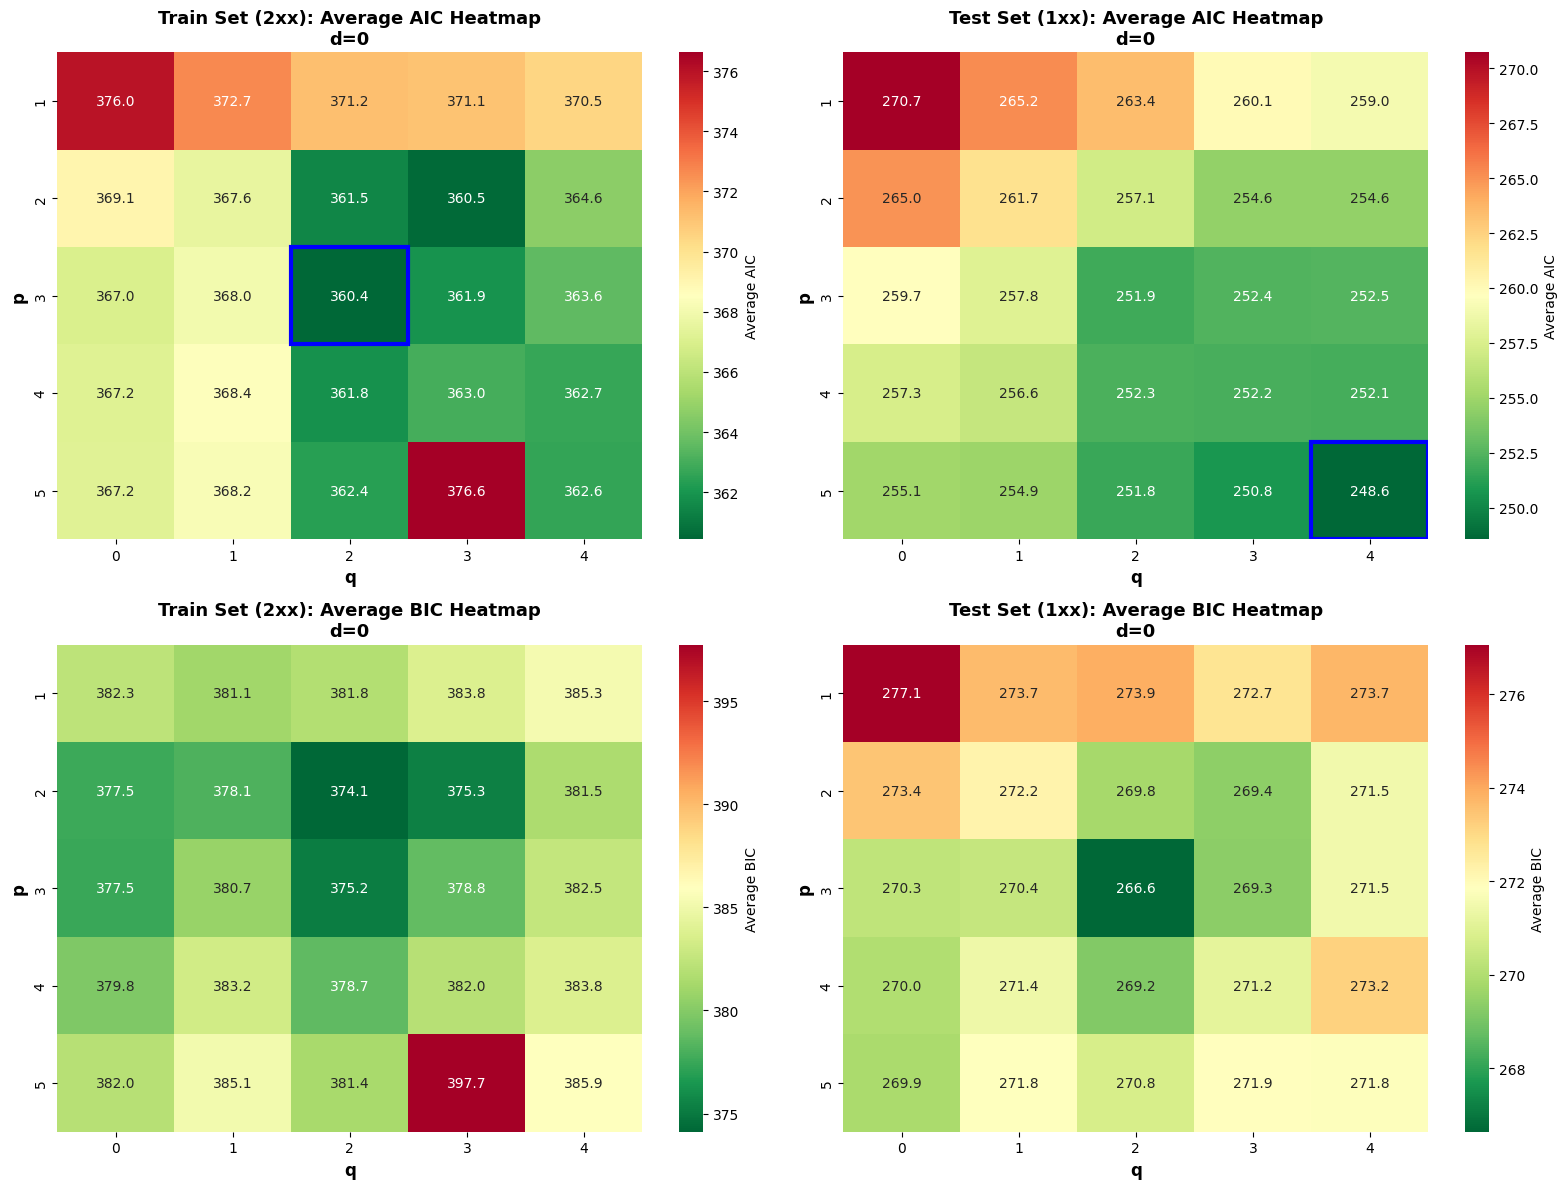


SUMMARY: AIC for all (p,q) combinations
 p  d  q  Train_AIC   Test_AIC        Diff Is_Original
 5  0  4 362.644120 248.566920 -114.077200            
 5  0  3 376.632856 250.763089 -125.869767            
 5  0  2 362.389273 251.769506 -110.619767            
 3  0  2 360.434219 251.865469 -108.568750           âœ“
 4  0  4 362.673273 252.059684 -110.613589            
 4  0  3 362.975957 252.162961 -110.812996            
 4  0  2 361.844922 252.280743 -109.564179            
 3  0  3 361.932104 252.449886 -109.482218            
 3  0  4 363.550064 252.473304 -111.076760            
 2  0  4 364.632982 254.594861 -110.038121            
 2  0  3 360.542700 254.604404 -105.938297            
 5  0  1 368.222892 254.949823 -113.273069            
 5  0  0 367.211359 255.111846 -112.099512            
 4  0  1 368.420108 256.614852 -111.805255            
 2  0  2 361.453858 257.123017 -104.330842            
 4  0  0 367.169426 257.340860 -109.828566            
 3  0  1 368.012761 25

In [9]:
# ====== FINE-TUNING GRID SEARCH: Kiểm tra tối ưu xung quanh (p,d,q) tốt nhất ======
# Từ kết quả trước: Best model ARIMA(3,0,2)
# Giờ kiểm tra chi tiết xung quanh p=3, q=2 để xác nhận tối ưu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("FINE-TUNING GRID SEARCH: Kiểm tra tối ưu xung quanh best model")
print("=" * 80)
print(f"Best model từ tìm kiếm trước: ARIMA({p_best},{d_best},{q_best})")
print(f"Sẽ test grid xung quanh: p ∈ [{max(0,p_best-2)}, {p_best+2}], q ∈ [{max(0,q_best-2)}, {q_best+2}]")
print("=" * 80)

# Define fine-tuning grid xung quanh best model
p_center = p_best
q_center = q_best
d_fixed = d_best

# Grid: ±2 xung quanh center
P_FINE = list(range(max(0, p_center-2), p_center+3))
Q_FINE = list(range(max(0, q_center-2), q_center+3))

print(f"\nFine-tuning grid:")
print(f"  P values: {P_FINE}")
print(f"  D value: {d_fixed} (fixed)")
print(f"  Q values: {Q_FINE}")
print(f"  Total combinations: {len(P_FINE)} x {len(Q_FINE)} = {len(P_FINE)*len(Q_FINE)}")
print("=" * 80)

# Create matrices to store results
aic_train_matrix = np.full((len(P_FINE), len(Q_FINE)), np.nan)
aic_test_matrix = np.full((len(P_FINE), len(Q_FINE)), np.nan)
bic_train_matrix = np.full((len(P_FINE), len(Q_FINE)), np.nan)
bic_test_matrix = np.full((len(P_FINE), len(Q_FINE)), np.nan)

# Evaluate each (p,q) combination
print("\nStep 1: Evaluating on TRAIN set (2xx records)...")
for i, p in enumerate(P_FINE):
    for j, q in enumerate(Q_FINE):
        aic_list = []
        bic_list = []
        for record_id, hr in hr_data.items():
            try:
                model = ARIMA(hr, order=(p, d_fixed, q))
                result = model.fit()
                aic_list.append(result.aic)
                bic_list.append(result.bic)
            except Exception:
                pass
        
        if len(aic_list) > 0:
            aic_train_matrix[i, j] = np.mean(aic_list)
            bic_train_matrix[i, j] = np.mean(bic_list)
        
        print(f"  ARIMA({p},{d_fixed},{q}): AIC={aic_train_matrix[i,j]:.2f} (n={len(aic_list)})")

print("\nStep 2: Evaluating on TEST set (1xx records)...")
for i, p in enumerate(P_FINE):
    for j, q in enumerate(Q_FINE):
        aic_list = []
        bic_list = []
        for record_id, hr in hr_data_test.items():
            try:
                model = ARIMA(hr, order=(p, d_fixed, q))
                result = model.fit()
                aic_list.append(result.aic)
                bic_list.append(result.bic)
            except Exception:
                pass
        
        if len(aic_list) > 0:
            aic_test_matrix[i, j] = np.mean(aic_list)
            bic_test_matrix[i, j] = np.mean(bic_list)
        
        print(f"  ARIMA({p},{d_fixed},{q}): AIC={aic_test_matrix[i,j]:.2f} (n={len(aic_list)})")

# Find optimal
train_min_idx = np.unravel_index(np.nanargmin(aic_train_matrix), aic_train_matrix.shape)
test_min_idx = np.unravel_index(np.nanargmin(aic_test_matrix), aic_test_matrix.shape)

p_optimal_train = P_FINE[train_min_idx[0]]
q_optimal_train = Q_FINE[train_min_idx[1]]
p_optimal_test = P_FINE[test_min_idx[0]]
q_optimal_test = Q_FINE[test_min_idx[1]]

print("\n" + "=" * 80)
print("OPTIMAL MODELS:")
print("-" * 80)
print(f"Train set (2xx): ARIMA({p_optimal_train},{d_fixed},{q_optimal_train}) - AIC={aic_train_matrix[train_min_idx]:.2f}")
print(f"Test set (1xx):  ARIMA({p_optimal_test},{d_fixed},{q_optimal_test}) - AIC={aic_test_matrix[test_min_idx]:.2f}")
print(f"Original best:   ARIMA({p_best},{d_best},{q_best})")

if p_optimal_train == p_best and q_optimal_train == q_best:
    print("\n✓ CONFIRMED: Model ban đầu ARIMA({},{},{}) LÀ TỐI ƯU trên train set!".format(p_best, d_best, q_best))
else:
    print("\n⚠ WARNING: Tìm thấy model tốt hơn trên train set!")

if p_optimal_test == p_best and q_optimal_test == q_best:
    print("✓ CONFIRMED: Model ban đầu ARIMA({},{},{}) LÀ TỐI ƯU trên test set!".format(p_best, d_best, q_best))
else:
    print("⚠ WARNING: Tìm thấy model tốt hơn trên test set!")
print("=" * 80)

# Visualize heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Create heatmaps
vmin_train = np.nanmin(aic_train_matrix)
vmax_train = np.nanmax(aic_train_matrix)
vmin_test = np.nanmin(aic_test_matrix)
vmax_test = np.nanmax(aic_test_matrix)

# Plot 1: Train AIC heatmap
sns.heatmap(aic_train_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=Q_FINE, yticklabels=P_FINE, 
            cbar_kws={'label': 'Average AIC'}, ax=axes[0,0],
            vmin=vmin_train, vmax=vmax_train)
axes[0,0].set_xlabel('q', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('p', fontsize=12, fontweight='bold')
axes[0,0].set_title(f'Train Set (2xx): Average AIC Heatmap\nd={d_fixed}', 
                     fontsize=13, fontweight='bold')
# Mark best model
axes[0,0].add_patch(plt.Rectangle((train_min_idx[1], train_min_idx[0]), 1, 1, 
                                   fill=False, edgecolor='blue', lw=3))

# Plot 2: Test AIC heatmap
sns.heatmap(aic_test_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=Q_FINE, yticklabels=P_FINE,
            cbar_kws={'label': 'Average AIC'}, ax=axes[0,1],
            vmin=vmin_test, vmax=vmax_test)
axes[0,1].set_xlabel('q', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('p', fontsize=12, fontweight='bold')
axes[0,1].set_title(f'Test Set (1xx): Average AIC Heatmap\nd={d_fixed}', 
                     fontsize=13, fontweight='bold')
# Mark best model
axes[0,1].add_patch(plt.Rectangle((test_min_idx[1], test_min_idx[0]), 1, 1, 
                                   fill=False, edgecolor='blue', lw=3))

# Plot 3: Train BIC heatmap
sns.heatmap(bic_train_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=Q_FINE, yticklabels=P_FINE,
            cbar_kws={'label': 'Average BIC'}, ax=axes[1,0])
axes[1,0].set_xlabel('q', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('p', fontsize=12, fontweight='bold')
axes[1,0].set_title(f'Train Set (2xx): Average BIC Heatmap\nd={d_fixed}', 
                     fontsize=13, fontweight='bold')

# Plot 4: Test BIC heatmap
sns.heatmap(bic_test_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
            xticklabels=Q_FINE, yticklabels=P_FINE,
            cbar_kws={'label': 'Average BIC'}, ax=axes[1,1])
axes[1,1].set_xlabel('q', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('p', fontsize=12, fontweight='bold')
axes[1,1].set_title(f'Test Set (1xx): Average BIC Heatmap\nd={d_fixed}', 
                     fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("SUMMARY: AIC for all (p,q) combinations")
print("=" * 80)
summary_data = []
for i, p in enumerate(P_FINE):
    for j, q in enumerate(Q_FINE):
        summary_data.append({
            'p': p,
            'd': d_fixed,
            'q': q,
            'Train_AIC': aic_train_matrix[i,j],
            'Test_AIC': aic_test_matrix[i,j],
            'Diff': aic_test_matrix[i,j] - aic_train_matrix[i,j],
            'Is_Original': '✓' if (p==p_best and q==q_best) else ''
        })

df_summary = pd.DataFrame(summary_data).sort_values('Test_AIC')
print(df_summary.to_string(index=False))

print("\n" + "=" * 80)
print("KẾT LUẬN:")
print("-" * 80)
print(f"Model ARIMA({p_best},{d_best},{q_best}) đã được kiểm tra kỹ xung quanh các giá trị p,q lân cận")
if p_optimal_test == p_best and q_optimal_test == q_best:
    print("✓ Model này LÀ TỐI ƯU trong vùng tìm kiếm!")
    print(f"  Test AIC = {aic_test_matrix[test_min_idx]:.2f}")
else:
    print(f"⚠ Model ARIMA({p_optimal_test},{d_fixed},{q_optimal_test}) có AIC tốt hơn trên test set")
    print(f"  Original: {aic_test_matrix[P_FINE.index(p_best), Q_FINE.index(q_best)]:.2f}")
    print(f"  Better:   {aic_test_matrix[test_min_idx]:.2f}")
    print(f"  Improvement: {aic_test_matrix[P_FINE.index(p_best), Q_FINE.index(q_best)] - aic_test_matrix[test_min_idx]:.2f}")
print("=" * 80)

## 7. ARIMA Rolling Forecast for HR

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Total HR samples (@ 1 Hz): 1806
Train: 1756s, Test (forecast): 50s
Plot window: last 100s (from sample 1706 to 1806)
Rolling ARIMA(7,0,4) forecast on last 50s...
âœ“ Forecast complete | MAE=1.18 bpm | RMSE=1.46 bpm

ðŸ“Š FORECAST PERFORMANCE METRICS:
   Mean Absolute Error (MAE):     1.1808 bpm
   Root Mean Squared Error (RMSE): 1.4630 bpm
   Forecast Horizon:               50 seconds
   Training Data:                  1756 seconds


Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Total HR samples (@ 1 Hz): 1806
Train: 1756s, Test (forecast): 50s
Plot window: last 100s (from sample 1706 to 1806)
Rolling ARIMA(7,0,4) forecast on last 50s...
âœ“ Forecast complete | MAE=1.18 bpm | RMSE=1.46 bpm

ðŸ“Š FORECAST PERFORMANCE METRICS:
   Mean Absolute Error (MAE):     1.1808 bpm
   Root Mean Squared Error (RMSE): 1.4630 bpm
   Forecast Horizon:               50 seconds
   Training Data:                  1756 seconds


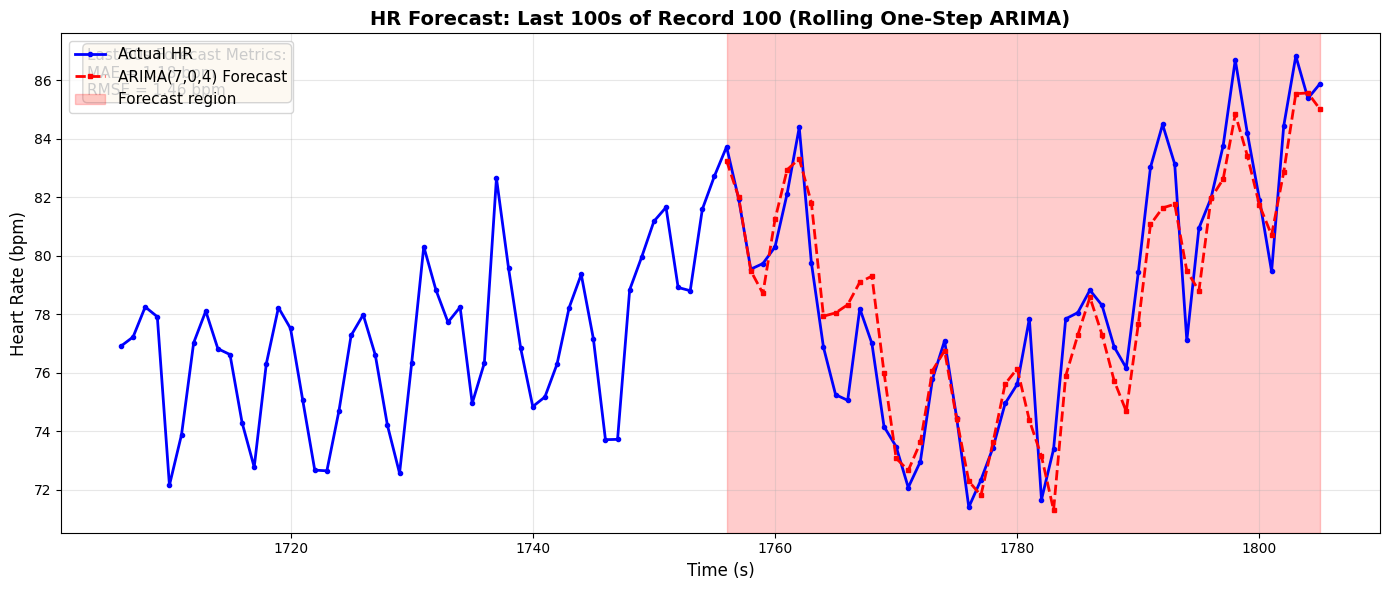


Forecast Results (last 50 seconds):
 Time (s from end)  Actual (bpm)  Forecast (bpm)  Error (bpm)  Abs Error (bpm)
               -50     83.720930       83.247798     0.473132         0.473132
               -49     81.934830       81.996205    -0.061375         0.061375
               -48     79.536732       79.479355     0.057377         0.057377
               -47     79.729030       78.709127     1.019903         1.019903
               -46     80.297398       81.239947    -0.942549         0.942549
               -45     82.117383       82.935812    -0.818430         0.818430
               -44     84.386279       83.314042     1.072237         1.072237
               -43     79.764646       81.815705    -2.051059         2.051059
               -42     76.868327       77.929801    -1.061474         1.061474
               -41     75.245216       78.041378    -2.796162         2.796162
               -40     75.052216       78.321975    -3.269760         3.269760
               

In [10]:
# =========================
# CELL — ARIMA rolling one-step forecast for LAST 50s of record 100
# Plot ONLY last 100s (actual + predicted)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import butter, filtfilt, iirnotch, medfilt, find_peaks
from statsmodels.tsa.arima.model import ARIMA

# ---------- 0) Load record 100 directly from WFDB ----------
RECORD = "100"
LEAD = 0  # usually MLII
record = wfdb.rdrecord(RECORD, pn_dir="mitdb")
fs = record.fs
ecg = record.p_signal[:, LEAD].astype(float)
sig_name = record.sig_name[LEAD]
t = np.arange(len(ecg)) / fs

# ---------- 1) 3 filters: baseline removal -> bandpass -> notch ----------
def remove_baseline_median(x, fs, w1_sec=0.2, w2_sec=0.6):
    w1 = int(max(3, (w1_sec*fs)//2*2 + 1))
    w2 = int(max(3, (w2_sec*fs)//2*2 + 1))
    b1 = medfilt(x, kernel_size=w1)
    baseline = medfilt(b1, kernel_size=w2)
    return x - baseline

def butter_bandpass(x, fs, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def notch(x, fs, f0=60.0, Q=30.0):
    w0 = f0 / (fs/2)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, x)

x = ecg
x_detr = remove_baseline_median(x, fs)
x_bp = butter_bandpass(x_detr, fs, 0.5, 40.0, order=4)
x_clean = notch(x_bp, fs, f0=60.0, Q=30.0)

# ---------- 2) R-peak detection -> RR, HR -> resample HR to 1 Hz ----------
def detect_rpeaks(ecg_filt, fs):
    # try WFDB XQRS first
    try:
        from wfdb import processing
        r = processing.xqrs_detect(sig=ecg_filt.astype(float), fs=fs)
        r = np.asarray(r, dtype=int)
        if len(r) > 20:
            return r
    except Exception:
        pass
    # fallback
    distance = int(0.25 * fs)  # >= 0.25s between peaks (~240 bpm)
    prom = np.std(ecg_filt) * 0.5
    r, _ = find_peaks(ecg_filt, distance=distance, prominence=prom)
    return r.astype(int)

def hampel(x, window=10, n_sigmas=3.0):
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    k = 1.4826
    y = x.copy()
    for i in range(n):
        lo, hi = max(0, i-window), min(n, i+window+1)
        w = x[lo:hi]
        med = np.nanmedian(w)
        mad = k * np.nanmedian(np.abs(w - med))
        if not np.isfinite(mad) or mad < 1e-9:
            continue
        if np.abs(x[i] - med) > n_sigmas * mad:
            y[i] = med
    return y

rpeaks = detect_rpeaks(x_clean, fs)
rr = np.diff(rpeaks) / fs
rr = np.clip(rr, 0.25, 2.5)         # basic physiological clamp
rr = hampel(rr, window=10, n_sigmas=3.0)

hr = 60.0 / rr
hr = np.clip(hr, 30, 220)
hr = hampel(hr, window=10, n_sigmas=3.0)
t_hr = rpeaks[1:] / fs

# resample to 1 Hz grid
t_end = int(np.floor(t[-1]))
t_grid = np.arange(0, t_end + 1, 1.0)  # 1 Hz
mask = np.isfinite(hr) & np.isfinite(t_hr)
hr_reg = np.interp(t_grid, t_hr[mask], hr[mask]).astype(float)
hr_reg = hr_reg[np.isfinite(hr_reg)]

# ---------- 3) Define last-100s window and rolling one-step forecast last-50s ----------
H = 50   # forecast horizon: last 50 seconds
W = 100  # plot window: last 100 seconds

T = len(hr_reg)
idx_test_start = T - H
idx_plot_start = T - W

# Split: train = all except last H, test = last H
y_train = hr_reg[:idx_test_start]
y_test = hr_reg[idx_test_start:]

print(f"Total HR samples (@ 1 Hz): {T}")
print(f"Train: {len(y_train)}s, Test (forecast): {len(y_test)}s")
print(f"Plot window: last {W}s (from sample {idx_plot_start} to {T})")
print("=" * 70)

# ---------- 4) ARIMA(7,0,4) rolling one-step forecast ----------
p, d, q = 7, 0, 4

forecasts = []
y_rolling = y_train.copy()

print(f"Rolling ARIMA({p},{d},{q}) forecast on last {H}s...")
for i in range(len(y_test)):
    try:
        model = ARIMA(y_rolling, order=(p, d, q))
        results = model.fit()
        fcast = float(results.get_forecast(steps=1).predicted_mean[0])
        forecasts.append(fcast)
        y_rolling = np.append(y_rolling, y_test[i])
    except Exception as e:
        print(f"  Forecast step {i}: Error - {type(e).__name__}, using last value")
        forecasts.append(y_rolling[-1])
        y_rolling = np.append(y_rolling, y_test[i])

forecasts = np.array(forecasts)

# Calculate metrics
errors = y_test - forecasts
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors**2))

print(f"✓ Forecast complete | MAE={mae:.2f} bpm | RMSE={rmse:.2f} bpm")
print("=" * 70)

# Print detailed metrics
print(f"\n📊 FORECAST PERFORMANCE METRICS:")
print(f"   Mean Absolute Error (MAE):     {mae:.4f} bpm")
print(f"   Root Mean Squared Error (RMSE): {rmse:.4f} bpm")
print(f"   Forecast Horizon:               {H} seconds")
print(f"   Training Data:                  {len(y_train)} seconds")
print("=" * 70)

# ---------- 5) Plot last W seconds: actual vs predicted ----------
t_plot = t_grid[idx_plot_start:T]
y_plot_actual = hr_reg[idx_plot_start:T]

# For predicted, we have forecasts for the last H seconds
# Pad with NaN for the part before forecasting starts
forecasts_plot = np.full(W, np.nan)
forecasts_plot[-H:] = forecasts

fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual
ax.plot(t_plot, y_plot_actual, 'b-', linewidth=2, label='Actual HR', marker='o', markersize=3)

# Plot predicted (last 50s only)
ax.plot(t_plot[-H:], forecasts, 'r--', linewidth=2, label=f'ARIMA({p},{d},{q}) Forecast', marker='s', markersize=3)

# Shade forecast region
ax.axvspan(t_plot[-H], t_plot[-1], alpha=0.2, color='red', label='Forecast region')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Heart Rate (bpm)', fontsize=12)
ax.set_title(f'HR Forecast: Last {W}s of Record 100 (Rolling One-Step ARIMA)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Add metrics box
textstr = f'Last {H}s Forecast Metrics:\nMAE = {mae:.2f} bpm\nRMSE = {rmse:.2f} bpm'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# ---------- 6) Results table ----------
df_forecast = pd.DataFrame({
    'Time (s from end)': -np.arange(H, 0, -1),
    'Actual (bpm)': y_test,
    'Forecast (bpm)': forecasts,
    'Error (bpm)': errors,
    'Abs Error (bpm)': np.abs(errors)
})

print("\nForecast Results (last 50 seconds):")
print(df_forecast.to_string(index=False))
print("\n✓ ARIMA forecast plot complete!")


## 8. ARIMA Rolling Forecast for RR

Total RR samples (@ 1 Hz): 1806
Train: 1756s, Test (forecast): 50s
Plot window: last 100s (from sample 1706 to 1806)
Using default RR order: ARIMA(2,0,2)
Rolling ARIMA(2,0,2) forecast on RR for last 50s...
âœ“ RR forecast complete | MAE=2.82 bpm | RMSE=3.49 bpm


Total RR samples (@ 1 Hz): 1806
Train: 1756s, Test (forecast): 50s
Plot window: last 100s (from sample 1706 to 1806)
Using default RR order: ARIMA(2,0,2)
Rolling ARIMA(2,0,2) forecast on RR for last 50s...
âœ“ RR forecast complete | MAE=2.82 bpm | RMSE=3.49 bpm


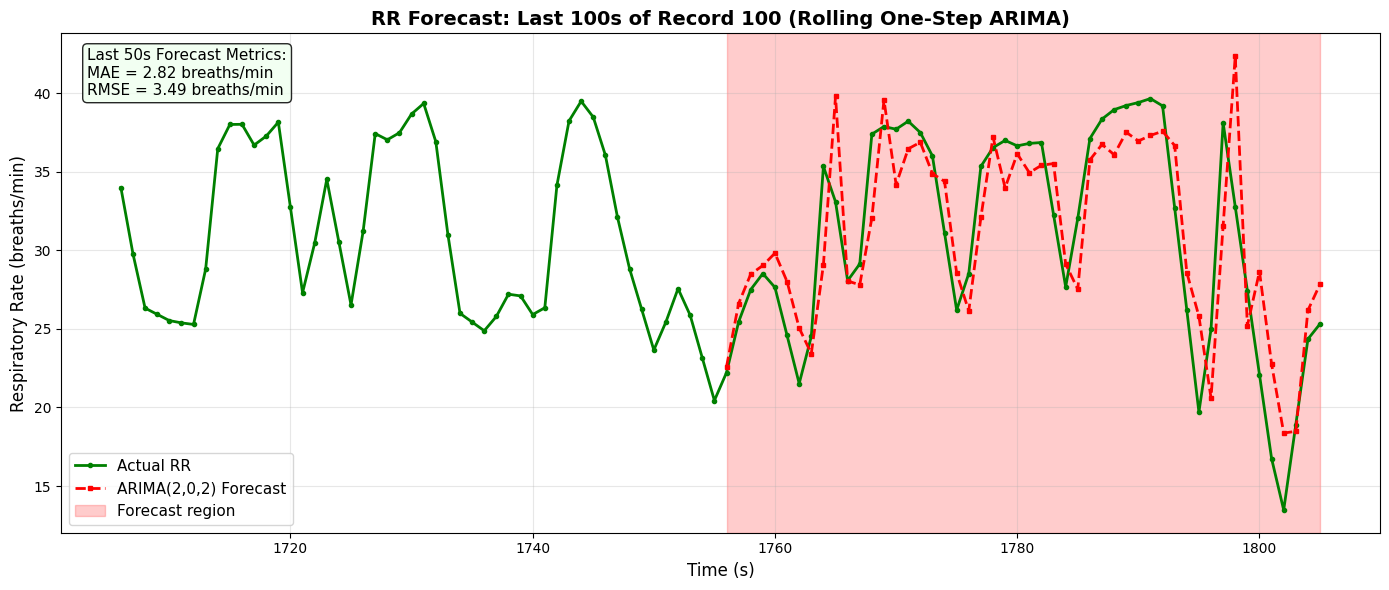


RR Forecast Results (last 50 seconds):
 Time (s from end)  Actual RR (breaths/min)  Forecast RR (breaths/min)     Error  Abs Error
               -50                22.220434                  22.588282 -0.367848   0.367848
               -49                25.450130                  26.616510 -1.166381   1.166381
               -48                27.507426                  28.489055 -0.981629   0.981629
               -47                28.527365                  29.040489 -0.513124   0.513124
               -46                27.643412                  29.826637 -2.183225   2.183225
               -45                24.583583                  28.015558 -3.431975   3.431975
               -44                21.523754                  25.059941 -3.536187   3.536187
               -43                24.519998                  23.429945  1.090052   1.090052
               -42                35.346705                  29.091335  6.255371   6.255371
               -41                33.096

In [11]:
 # =========================
# CELL 10 — ARIMA rolling one-step forecast for RR (Respiratory Rate)
# Plot ONLY last 100s (actual + predicted), forecast last 50s
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from statsmodels.tsa.arima.model import ARIMA

# Reuse cleaned ECG from previous cell if available; otherwise compute from ecg
if "x_clean" not in globals():
    if "ecg" not in globals() or "fs" not in globals():
        raise ValueError("Cần chạy cell dự đoán HR trước để có ecg/fs/x_clean.")
    
    from scipy.signal import iirnotch, medfilt
    def remove_baseline_median(x, fs, w1_sec=0.2, w2_sec=0.6):
        w1 = int(max(3, (w1_sec*fs)//2*2 + 1))
        w2 = int(max(3, (w2_sec*fs)//2*2 + 1))
        b1 = medfilt(x, kernel_size=w1)
        baseline = medfilt(b1, kernel_size=w2)
        return x - baseline
    
    def butter_bandpass(x, fs, low=0.5, high=40.0, order=4):
        nyq = 0.5 * fs
        b, a = butter(order, [low/nyq, high/nyq], btype="band")
        return filtfilt(b, a, x)
    
    def notch(x, fs, f0=60.0, Q=30.0):
        w0 = f0 / (fs/2)
        b, a = iirnotch(w0, Q)
        return filtfilt(b, a, x)
    
    x_detr = remove_baseline_median(ecg, fs)
    x_bp = butter_bandpass(x_detr, fs, 0.5, 40.0, order=4)
    x_clean = notch(x_bp, fs, f0=60.0, Q=30.0)

# ---------- 1) Extract respiratory component from ECG (EDR) ----------
b_rr, a_rr = butter(2, [0.1/(fs/2), 0.5/(fs/2)], btype="band")
x_rr = filtfilt(b_rr, a_rr, x_clean)

# Detect respiratory peaks
min_distance = int(1.5 * fs)  # >= 1.5s between breaths (~40 breaths/min max)
prom = max(1e-6, 0.2 * np.std(x_rr))
resp_peaks, _ = find_peaks(x_rr, distance=min_distance, prominence=prom)

if len(resp_peaks) < 20:
    raise ValueError("Không đủ respiratory peaks để forecast RR. Hãy tăng thời lượng tín hiệu hoặc nới điều kiện peak.")

# RR time series (breaths/min)
resp_intervals = np.diff(resp_peaks) / fs
resp_intervals = np.clip(resp_intervals, 1.5, 8.0)
rr_bpm = 60.0 / resp_intervals
t_rr = resp_peaks[1:] / fs

# Resample RR to 1 Hz
if "t_grid" in globals():
    rr_t_grid = t_grid.copy()
else:
    t_end = int(np.floor(len(ecg) / fs))
    rr_t_grid = np.arange(0, t_end + 1, 1.0)

mask_rr = np.isfinite(rr_bpm) & np.isfinite(t_rr)
rr_reg = np.interp(rr_t_grid, t_rr[mask_rr], rr_bpm[mask_rr]).astype(float)
rr_reg = rr_reg[np.isfinite(rr_reg)]

# ---------- 2) Define rolling one-step setup ----------
H = 50   # forecast horizon: last 50 seconds
W = 100  # plot window: last 100 seconds

T = len(rr_reg)
if T <= max(H, W) + 10:
    raise ValueError(f"Chuỗi RR quá ngắn (T={T}) để forecast {H}s và plot {W}s.")

idx_test_start = T - H
idx_plot_start = T - W

y_train = rr_reg[:idx_test_start]
y_test = rr_reg[idx_test_start:]

print(f"Total RR samples (@ 1 Hz): {T}")
print(f"Train: {len(y_train)}s, Test (forecast): {len(y_test)}s")
print(f"Plot window: last {W}s (from sample {idx_plot_start} to {T})")
print("=" * 70)

# ---------- 3) ARIMA rolling one-step forecast ----------
if "best_rr_order" in globals() and best_rr_order is not None:
    p, d, q = best_rr_order
    print(f"Using tuned RR order: ARIMA({p},{d},{q})")
else:
    p, d, q = 2, 0, 2
    print(f"Using default RR order: ARIMA({p},{d},{q})")
forecasts_rr = []
y_rolling = y_train.copy()

print(f"Rolling ARIMA({p},{d},{q}) forecast on RR for last {H}s...")
for i in range(len(y_test)):
    try:
        model = ARIMA(y_rolling, order=(p, d, q))
        results = model.fit()
        fcast = float(results.get_forecast(steps=1).predicted_mean[0])
        forecasts_rr.append(fcast)
        y_rolling = np.append(y_rolling, y_test[i])
    except Exception as e:
        print(f"  Forecast step {i}: Error - {type(e).__name__}, using last value")
        forecasts_rr.append(y_rolling[-1])
        y_rolling = np.append(y_rolling, y_test[i])

forecasts_rr = np.array(forecasts_rr)

# Metrics
errors_rr = y_test - forecasts_rr
mae_rr = np.mean(np.abs(errors_rr))
rmse_rr = np.sqrt(np.mean(errors_rr**2))

print(f"✓ RR forecast complete | MAE={mae_rr:.2f} bpm | RMSE={rmse_rr:.2f} bpm")
print("=" * 70)

# ---------- 4) Plot last W seconds ----------
t_plot = rr_t_grid[idx_plot_start:T]
y_plot_actual = rr_reg[idx_plot_start:T]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t_plot, y_plot_actual, color='green', linewidth=2, label='Actual RR', marker='o', markersize=3)
ax.plot(t_plot[-H:], forecasts_rr, 'r--', linewidth=2, label=f'ARIMA({p},{d},{q}) Forecast', marker='s', markersize=3)
ax.axvspan(t_plot[-H], t_plot[-1], alpha=0.2, color='red', label='Forecast region')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Respiratory Rate (breaths/min)', fontsize=12)
ax.set_title(f'RR Forecast: Last {W}s of Record 100 (Rolling One-Step ARIMA)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

textstr = f'Last {H}s Forecast Metrics:\nMAE = {mae_rr:.2f} breaths/min\nRMSE = {rmse_rr:.2f} breaths/min'
props = dict(boxstyle='round', facecolor='honeydew', alpha=0.85)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# ---------- 5) Results table ----------
df_rr_forecast = pd.DataFrame({
    'Time (s from end)': -np.arange(H, 0, -1),
    'Actual RR (breaths/min)': y_test,
    'Forecast RR (breaths/min)': forecasts_rr,
    'Error': errors_rr,
    'Abs Error': np.abs(errors_rr)
})

print("\nRR Forecast Results (last 50 seconds):")
print(df_rr_forecast.to_string(index=False))
print("\n✓ RR rolling one-step forecast plot complete!")

In [12]:
# =========================
# CELL 11 — Auto-tuning ARIMA (p,d,q) for RR using AIC
# =========================
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

if "rr_reg" not in globals():
    raise ValueError("Cần chạy Cell 10 trước để tạo rr_reg.")

# Use same horizon as RR forecast cell
H_tune = 50
y = np.asarray(rr_reg, dtype=float)
y = y[np.isfinite(y)]

if len(y) <= H_tune + 30:
    raise ValueError(f"Chuỗi RR quá ngắn để auto-tuning: len={len(y)}")

y_train = y[:-H_tune]

# Search space (can expand if needed)
P_RANGE = range(0, 6)
D_RANGE = range(0, 3)
Q_RANGE = range(0, 6)

rows = []
best_aic = np.inf
best_rr_order = None

print("=" * 70)
print("Auto-tuning RR ARIMA by AIC...")
print(f"Train length: {len(y_train)} | Grid: {len(list(P_RANGE))*len(list(D_RANGE))*len(list(Q_RANGE))} models")

for p in P_RANGE:
    for d in D_RANGE:
        for q in Q_RANGE:
            try:
                model = ARIMA(y_train, order=(p, d, q))
                result = model.fit()
                aic = float(result.aic)
                bic = float(result.bic)
                rows.append({"p": p, "d": d, "q": q, "AIC": aic, "BIC": bic})

                if np.isfinite(aic) and aic < best_aic:
                    best_aic = aic
                    best_rr_order = (p, d, q)
            except Exception:
                continue

if best_rr_order is None:
    raise RuntimeError("Auto-tuning thất bại: không fit được model nào.")

df_rr_tuning = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
print("\nTop 10 models by AIC:")
print(df_rr_tuning.head(10).to_string(index=False))

print("\n" + "=" * 70)
print(f"Best RR order by AIC: ARIMA({best_rr_order[0]},{best_rr_order[1]},{best_rr_order[2]})")
print(f"Best AIC: {best_aic:.3f}")
print("Biến đã lưu: best_rr_order")
print("=" * 70)

Auto-tuning RR ARIMA by AIC...
Train length: 1756 | Grid: 108 models

Top 10 models by AIC:
 p  d  q         AIC         BIC
 0  1  5 8681.678286 8714.499631
 1  1  4 8681.774233 8714.595578
 1  1  3 8681.776246 8709.127367
 2  1  3 8681.966110 8714.787455
 0  1  4 8682.131697 8709.482818
 1  0  2 8682.542150 8709.896119
 1  1  5 8682.561463 8720.853032
 1  0  3 8683.002003 8715.826765
 0  0  4 8683.052580 8715.877343
 2  0  2 8683.264207 8716.088969

Best RR order by AIC: ARIMA(0,1,5)
Best AIC: 8681.678
Biáº¿n Ä‘Ã£ lÆ°u: best_rr_order


## 9. SARIMA Rolling Forecast

Record: 100
Total samples: 1806 | Train: 1756 | Test(last 50s): 50
SARIMA order: (3, 1, 3), seasonal_order: (0, 0, 1, 12)
MAE  = 2.0553
MSE  = 5.8474
RMSE = 2.4181


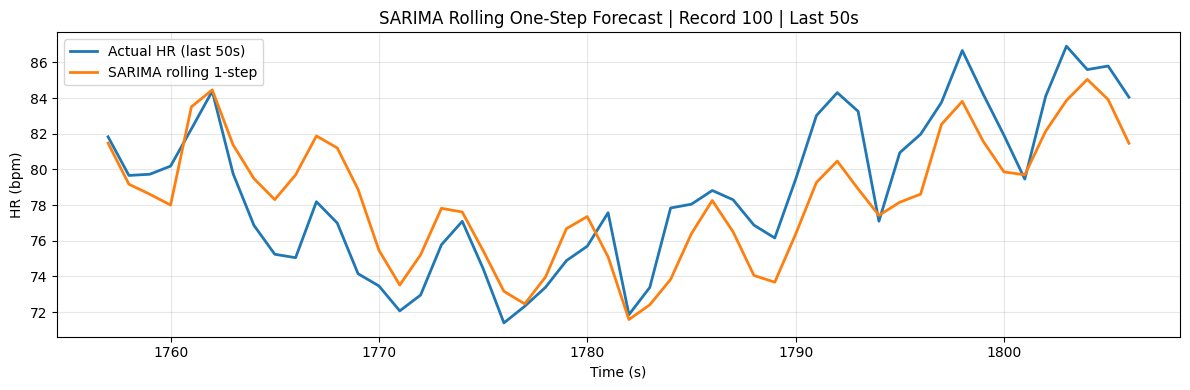

In [1]:
# CELL SARIMA-Rolling-50s — train full trước 50s cuối, rolling one-step forecast 50s cuối
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== Config =====
H = 50
record_id = "100"
order = (3, 1, 3)
seasonal_order = (0, 0, 1, 12)

# Nếu đã có HR_test từ các cell trước thì dùng lại, không thì tự tạo HR series từ annotation
if "HR_test" in globals() and record_id in HR_test:
    s = HR_test[record_id].dropna().astype(float)
else:
    pn_dir = "mitdb"
    ann = wfdb.rdann(record_id, "atr", pn_dir=pn_dir)
    hdr = wfdb.rdheader(record_id, pn_dir=pn_dir)
    fs = hdr.fs

    beat_symbols = set(["N","L","R","A","a","J","S","V","F","e","j","E","/","f","Q"])
    r_samples = np.array([x for x, sym in zip(ann.sample, ann.symbol) if sym in beat_symbols], dtype=int)

    rr = np.diff(r_samples) / fs
    t_hr = r_samples[1:] / fs
    hr = 60.0 / rr

    mask_phys = (rr >= 0.25) & (rr <= 2.5)
    s = pd.Series(hr[mask_phys], index=t_hr[mask_phys]).dropna().astype(float)

# Nếu index không đều theo giây, nội suy về 1 Hz cho forecast ổn định
if not np.issubdtype(np.asarray(s.index).dtype, np.number):
    s = pd.Series(s.values, index=np.arange(len(s)))

idx = np.arange(int(np.floor(s.index.min())), int(np.ceil(s.index.max())) + 1)
s_1hz = pd.Series(np.interp(idx, s.index.values.astype(float), s.values.astype(float)), index=idx)

if len(s_1hz) <= H + 30:
    raise ValueError(f"Series quá ngắn: len={len(s_1hz)} không đủ cho H={H}")

# ===== Split: train = toàn bộ trước 50s cuối, test = 50s cuối =====
train = s_1hz.iloc[:-H]
test = s_1hz.iloc[-H:]

print(f"Record: {record_id}")
print(f"Total samples: {len(s_1hz)} | Train: {len(train)} | Test(last {H}s): {len(test)}")
print(f"SARIMA order: {order}, seasonal_order: {seasonal_order}")

# ===== Rolling one-step with true update =====
model = SARIMAX(
    train.values,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res = model.fit(disp=False, maxiter=100)

preds = []
res_roll = res
for y_true in test.values:
    y_hat = float(res_roll.forecast(steps=1)[0])
    preds.append(y_hat)
    # cập nhật bằng giá trị thật vừa quan sát (rolling one-step)
    res_roll = res_roll.append([float(y_true)], refit=False)

pred = np.array(preds, dtype=float)

ae = mean_absolute_error(test.values, pred)
mse = mean_squared_error(test.values, pred)
rmse = float(np.sqrt(mse))

print(f"MAE  = {ae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

# ===== Plot =====
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual HR (last 50s)", linewidth=2)
plt.plot(test.index, pred, label="SARIMA rolling 1-step", linewidth=2)
plt.title(f"SARIMA Rolling One-Step Forecast | Record {record_id} | Last {H}s")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. SARIMA Tuning & Re-run

Searching best (p,d,q) ...
  New best: order=(0, 0, 0), AIC=17842.62
  New best: order=(0, 0, 1), AIC=16055.02
  New best: order=(0, 0, 2), AIC=14926.50
  New best: order=(0, 0, 3), AIC=14057.90
  New best: order=(0, 1, 0), AIC=10526.70
  New best: order=(0, 1, 1), AIC=9489.74
  New best: order=(0, 1, 2), AIC=9487.37
  New best: order=(0, 1, 3), AIC=9452.92


c:\Users\MY PC\.pyenv\pyenv-win\versions\3.12.3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  New best: order=(2, 1, 2), AIC=9416.93
  New best: order=(2, 1, 3), AIC=9071.66


c:\Users\MY PC\.pyenv\pyenv-win\versions\3.12.3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  New best: order=(3, 1, 3), AIC=9014.57

Best pdq: (3, 1, 3) | seasonal_order: (0, 0, 1, 12) | AIC: 9014.57

Rerun with tuned pdq
MAE  = 2.0553
MSE  = 5.8474
RMSE = 2.4181


,p,d,q,AIC
0,3,1,3,9014.566964
1,2,1,3,9071.663110
2,3,1,2,9362.552973
3,2,1,2,9416.932276
4,0,1,3,9452.924321
5,1,1,3,9458.518275
6,3,1,1,9464.379565
7,1,0,3,9465.315475
8,2,1,1,9479.680711
9,1,1,2,9485.626074


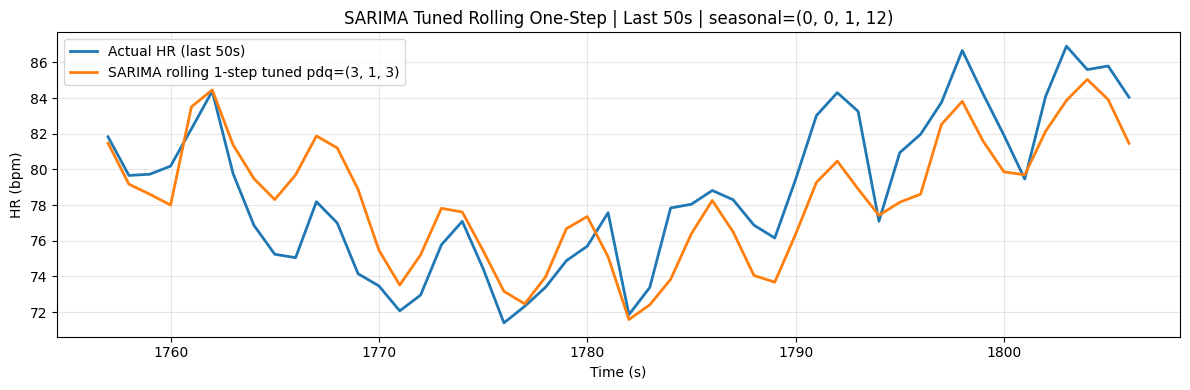

In [2]:
# CELL SARIMA-Tune-pdq-and-Rerun — tìm best (p,d,q) rồi chạy lại rolling one-step 50s cuối
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===== Input =====
H = 50
if "seasonal_order" not in globals():
    seasonal_order = (0, 0, 1, 12)

# Dùng train/test đã có từ cell trước; nếu chưa có thì tạo từ s_1hz
if "train" not in globals() or "test" not in globals():
    if "s_1hz" not in globals():
        raise ValueError("Chưa có dữ liệu. Hãy chạy cell SARIMA-Rolling-50s trước.")
    train = s_1hz.iloc[:-H]
    test = s_1hz.iloc[-H:]

# ===== Grid search best (p,d,q) by AIC on TRAIN =====
P_RANGE = [0, 1, 2, 3]
D_RANGE = [0, 1]
Q_RANGE = [0, 1, 2, 3]

best_aic = np.inf
best_order = None
results = []

print("Searching best (p,d,q) ...")
for p in P_RANGE:
    for d in D_RANGE:
        for q in Q_RANGE:
            try:
                m = SARIMAX(
                    train.values.astype(float),
                    order=(p, d, q),
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=80)

                aic = float(m.aic)
                results.append((p, d, q, aic))
                if np.isfinite(aic) and aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
                    print(f"  New best: order={best_order}, AIC={best_aic:.2f}")
            except Exception:
                continue

if best_order is None:
    raise RuntimeError("Không tìm được model SARIMA hợp lệ trong grid.")

print("\nBest pdq:", best_order, "| seasonal_order:", seasonal_order, "| AIC:", round(best_aic, 2))

# Lưu để dùng lại ở các cell sau
SARIMA_BEST_PDQ = best_order

# ===== Rerun rolling one-step forecast on last 50s =====
res0 = SARIMAX(
    train.values.astype(float),
    order=SARIMA_BEST_PDQ,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=100)

preds = []
res_roll = res0
for y_true in test.values.astype(float):
    y_hat = float(res_roll.forecast(steps=1)[0])
    preds.append(y_hat)
    res_roll = res_roll.append([y_true], refit=False)

pred = np.array(preds, dtype=float)
mae = mean_absolute_error(test.values, pred)
mse = mean_squared_error(test.values, pred)
rmse = float(np.sqrt(mse))

print("\nRerun with tuned pdq")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

# bảng top 10 theo AIC
rank_df = pd.DataFrame(results, columns=["p", "d", "q", "AIC"]).sort_values("AIC").reset_index(drop=True)
display(rank_df.head(10))

# plot
plt.figure(figsize=(12, 4))
plt.plot(test.index, test.values, label="Actual HR (last 50s)", linewidth=2)
plt.plot(test.index, pred, label=f"SARIMA rolling 1-step tuned pdq={SARIMA_BEST_PDQ}", linewidth=2)
plt.title(f"SARIMA Tuned Rolling One-Step | Last {H}s | seasonal={seasonal_order}")
plt.xlabel("Time (s)")
plt.ylabel("HR (bpm)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 11. ARIMA vs SARIMA Evaluation

In [7]:
# =========================
# CELL 12 — ARIMA vs SARIMA evaluation on preprocessed 2xx records
# Preprocessing used in process_record_to_hr():
# 1) Band-pass 0.5-40 Hz
# 2) Remove baseline wander
# 3) Remove power-line noise (50/60 Hz notch)
# =========================
import os
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

if "process_record_to_hr" not in globals():
    raise ValueError("Chưa có hàm process_record_to_hr. Hãy chạy Cell 6 trước.")

DB_PATH = r"C:\Users\MY PC\Downloads\time series project\mitdb"
MAX_DURATION_EVAL = 300
H = 50

# ARIMA/SARIMA settings
ARIMA_ORDER = (7, 0, 4)
SEASONAL_ORDER = (1, 0, 1, 10)

# Discover available 2xx records from local .hea files
hea_files = [f for f in os.listdir(DB_PATH) if f.endswith(".hea") and f[:3].isdigit() and f.startswith("2")]
available_2xx = sorted(list({f.split(".")[0] for f in hea_files}))

if len(available_2xx) == 0:
    raise ValueError("Không tìm thấy record 2xx trong DB_PATH.")

print("=" * 90)
print("ARIMA vs SARIMA on preprocessed 2xx records")
print(f"Using preprocessing pipeline from process_record_to_hr()")
print(f"Records found: {len(available_2xx)}")
print(f"ARIMA order: {ARIMA_ORDER} | SARIMA seasonal_order: {SEASONAL_ORDER}")
print("=" * 90)

rows = []
failed_records = []

for rid in available_2xx:
    hr = process_record_to_hr(rid, db_path=DB_PATH, max_duration=MAX_DURATION_EVAL)
    if hr is None or len(hr) <= H + 30:
        failed_records.append((rid, "short_or_invalid_series"))
        continue

    y = np.asarray(hr, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) <= H + 30:
        failed_records.append((rid, "non_finite_after_clean"))
        continue

    y_train = y[:-H]
    y_test = y[-H:]

    # ARIMA forecast
    try:
        arima_fit = ARIMA(y_train, order=ARIMA_ORDER).fit()
        pred_arima = np.asarray(arima_fit.forecast(steps=H), dtype=float)
    except Exception as e:
        failed_records.append((rid, f"arima_fail:{type(e).__name__}"))
        continue

    # SARIMA forecast
    try:
        sarima_fit = SARIMAX(
            y_train,
            order=ARIMA_ORDER,
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        pred_sarima = np.asarray(sarima_fit.forecast(steps=H), dtype=float)
    except Exception as e:
        failed_records.append((rid, f"sarima_fail:{type(e).__name__}"))
        continue

    # Stabilize predictions to avoid exploding errors
    lo = float(np.nanpercentile(y_train, 1))
    hi = float(np.nanpercentile(y_train, 99))
    pred_arima = np.nan_to_num(pred_arima, nan=y_train[-1], posinf=hi, neginf=lo)
    pred_sarima = np.nan_to_num(pred_sarima, nan=y_train[-1], posinf=hi, neginf=lo)
    pred_arima = np.clip(pred_arima, lo, hi)
    pred_sarima = np.clip(pred_sarima, lo, hi)

    arima_err = y_test - pred_arima
    sarima_err = y_test - pred_sarima

    rows.append({
        "Record": rid,
        "ARIMA_MAE": float(np.mean(np.abs(arima_err))),
        "ARIMA_MSE": float(np.mean(arima_err ** 2)),
        "ARIMA_RMSE": float(np.sqrt(np.mean(arima_err ** 2))),
        "SARIMA_MAE": float(np.mean(np.abs(sarima_err))),
        "SARIMA_MSE": float(np.mean(sarima_err ** 2)),
        "SARIMA_RMSE": float(np.sqrt(np.mean(sarima_err ** 2))),
    })

if len(rows) == 0:
    raise RuntimeError("Không có record hợp lệ để đánh giá ARIMA/SARIMA.")

per_record_scores_2xx = pd.DataFrame(rows).sort_values("Record").reset_index(drop=True)

full_scores_2xx = pd.DataFrame([
    {
        "Model": "ARIMA",
        "MAE": float(per_record_scores_2xx["ARIMA_MAE"].mean()),
        "MSE": float(per_record_scores_2xx["ARIMA_MSE"].mean()),
        "RMSE": float(per_record_scores_2xx["ARIMA_RMSE"].mean()),
    },
    {
        "Model": "SARIMA",
        "MAE": float(per_record_scores_2xx["SARIMA_MAE"].mean()),
        "MSE": float(per_record_scores_2xx["SARIMA_MSE"].mean()),
        "RMSE": float(per_record_scores_2xx["SARIMA_RMSE"].mean()),
    },
]).sort_values("RMSE").reset_index(drop=True)

print(f"Valid records: {len(per_record_scores_2xx)}")
if failed_records:
    print(f"Skipped records: {len(failed_records)}")

print("\nPer-record ARIMA/SARIMA metrics:")
print(per_record_scores_2xx.to_string(index=False))

print("\nOverall mean metrics (across records):")
print(full_scores_2xx.to_string(index=False))

ARIMA vs SARIMA on preprocessed 2xx records
Using preprocessing pipeline from process_record_to_hr()
Records found: 25
ARIMA order: (7, 0, 4) | SARIMA seasonal_order: (1, 0, 1, 10)
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
F

## 12. Plot Comparison: ARIMA vs SARIMA

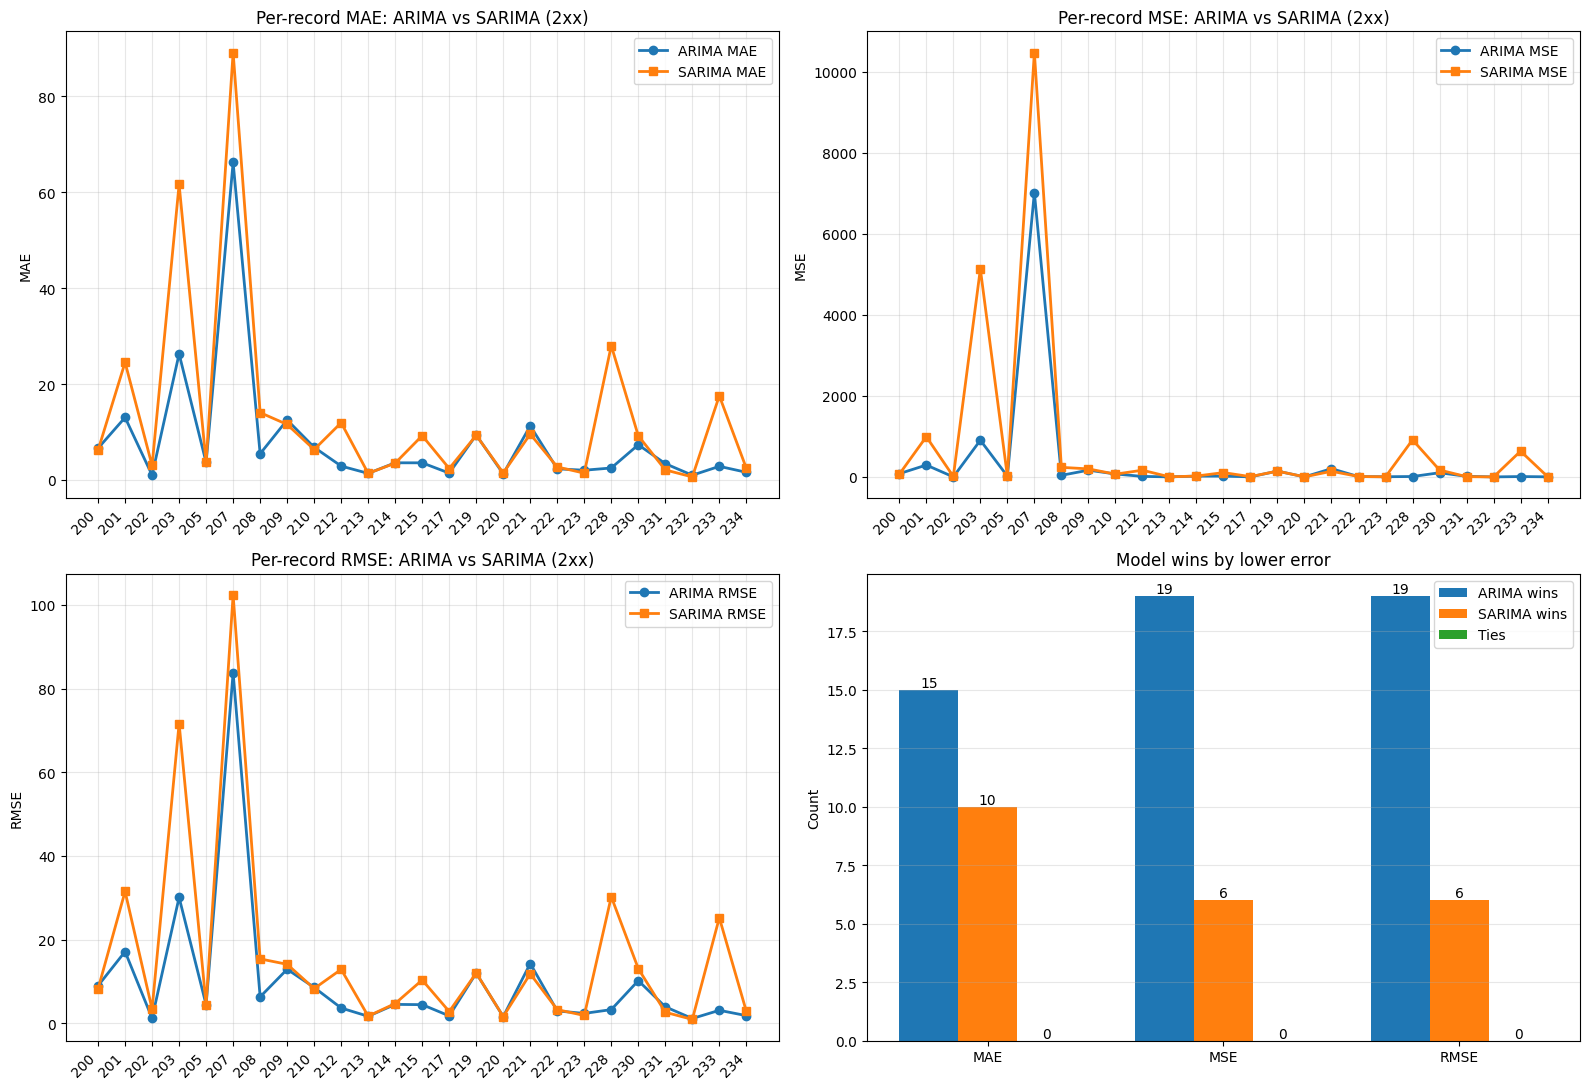

In [25]:
# =========================
# CELL 13 — Plot comparison ARIMA vs SARIMA (MAE, MSE, RMSE)
# =========================
import numpy as np
import matplotlib.pyplot as plt

if "per_record_scores_2xx" not in globals():
    raise ValueError("Chưa có per_record_scores_2xx. Hãy chạy Cell 12 trước.")

df_cmp = per_record_scores_2xx.copy()
df_cmp["Record"] = df_cmp["Record"].astype(str)
df_cmp = df_cmp.sort_values("Record").reset_index(drop=True)

x = np.arange(len(df_cmp))
metrics = ["MAE", "MSE", "RMSE"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

# (1) (2) (3) Line charts per metric
for i, m in enumerate(metrics):
    ax = axes[i]
    ax.plot(x, df_cmp[f"ARIMA_{m}"].values, marker="o", linewidth=2, label=f"ARIMA {m}")
    ax.plot(x, df_cmp[f"SARIMA_{m}"].values, marker="s", linewidth=2, label=f"SARIMA {m}")
    ax.set_xticks(x)
    ax.set_xticklabels(df_cmp["Record"].tolist(), rotation=45, ha="right")
    ax.set_ylabel(m)
    ax.set_title(f"Per-record {m}: ARIMA vs SARIMA (2xx)")
    ax.grid(True, alpha=0.3)
    ax.legend()

# (4) Win-count grouped bar for all 3 metrics
ax4 = axes[3]
bar_labels = metrics
arima_wins = [int((df_cmp[f"ARIMA_{m}"] < df_cmp[f"SARIMA_{m}"]).sum()) for m in metrics]
sarima_wins = [int((df_cmp[f"SARIMA_{m}"] < df_cmp[f"ARIMA_{m}"]).sum()) for m in metrics]
ties = [int((df_cmp[f"SARIMA_{m}"] == df_cmp[f"ARIMA_{m}"]).sum()) for m in metrics]

w = 0.25
pos = np.arange(len(bar_labels))
b1 = ax4.bar(pos - w, arima_wins, width=w, label="ARIMA wins")
b2 = ax4.bar(pos, sarima_wins, width=w, label="SARIMA wins")
b3 = ax4.bar(pos + w, ties, width=w, label="Ties")
ax4.set_xticks(pos)
ax4.set_xticklabels(bar_labels)
ax4.set_ylabel("Count")
ax4.set_title("Model wins by lower error")
ax4.grid(True, axis="y", alpha=0.3)
ax4.legend()

for bars in [b1, b2, b3]:
    for b in bars:
        h = b.get_height()
        ax4.text(b.get_x() + b.get_width()/2, h, str(int(h)), ha="center", va="bottom")

plt.tight_layout()
plt.show()
